In [1]:
import pickle
import numpy as np
import pandas as pd

import scanpy as sc
import anndata
import random

import torch
from torch import nn
from torch import optim
from torch.nn import functional as F

import os
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from seaborn import heatmap, lineplot, clustermap
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
#from keras.datasets import mnist
from scipy.stats import mode
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score
#import igraph as ig
#import louvain as lv
print("MPS Available:", torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
random.seed(10)

MPS Available: True


In [2]:
from sklearn.datasets import fetch_openml

In [3]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')
x_train, y_train = mnist.data, mnist.target
x_train = np.array(x_train, dtype=np.float32) 
x_train = x_train.reshape(len(x_train), 28, 28)
y_train = np.array(y_train, dtype=np.int64)

In [4]:
from contrastive_NMF import nmf_sse
from contrastive_NMF import nmf_poisson
from contrastive_NMF import nmf_poisson_minibatch
from contrastive_NMF import contrastive_nmf_sse
from contrastive_NMF import contrastive_nmf_poisson
from contrastive_NMF import contrastive_nmf_poisson_minibatch

In [5]:
def resize_and_crop(img, size=(28,28), crop_type='middle'):
    # If height is higher we resize vertically, if not we resize horizontally
    # Get current and desired ratio for the images
    img_ratio = img.size[0] / float(img.size[1])
    ratio = size[0] / float(size[1])
    # The image is scaled/cropped vertically or horizontally
    # depending on the ratio
    if ratio > img_ratio:
        img = img.resize((
            size[0],
            int(round(size[0] * img.size[1] / img.size[0]))),
            Image.Resampling.LANCZOS)
        # Crop in the top, middle or bottom
        if crop_type == 'top':
            box = (0, 0, img.size[0], size[1])
        elif crop_type == 'middle':
            box = (
                0,
                int(round((img.size[1] - size[1]) / 2)),
                img.size[0],
                int(round((img.size[1] + size[1]) / 2)))
        elif crop_type == 'bottom':
            box = (0, img.size[1] - size[1], img.size[0], img.size[1])
        else:
            raise ValueError('ERROR: invalid value for crop_type')
        img = img.crop(box)
    elif ratio < img_ratio:
        img = img.resize((
            int(round(size[1] * img.size[0] / img.size[1])),
            size[1]),
            Image.Resampling.LANCZOS)
        # Crop in the top, middle or bottom
        if crop_type == 'top':
            box = (0, 0, size[0], img.size[1])
        elif crop_type == 'middle':
            box = (
                int(round((img.size[0] - size[0]) / 2)),
                0,
                int(round((img.size[0] + size[0]) / 2)),
                img.size[1])
        elif crop_type == 'bottom':
            box = (
                img.size[0] - size[0],
                0,
                img.size[0],
                img.size[1])
        else:
            raise ValueError('ERROR: invalid value for crop_type')
        img = img.crop(box)
    else:
        img = img.resize((
            size[0],
            size[1]),
            Image.Resampling.LANCZOS)
    # If the scale is the same, we do not need to crop
    return img

In [6]:
from PIL import Image
#from utils import resize_and_crop
import os

IMAGE_PATH = '/Users/lyx/Desktop/PhD/3 Contrastive LDA/Simulation/Simulation on MINIST/Background/n11939491/' #Replace with your own path to downloaded images
        
natural_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
for filename in os.listdir(IMAGE_PATH):
    if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
        try:
            im = Image.open(os.path.join(IMAGE_PATH,filename))
            im = im.convert(mode="L") #convert to grayscale
            im = resize_and_crop(im) #resize and crop each picture to be 100px by 100px
            natural_images.append(np.reshape(im, [784])) 
        except Exception as e:
            pass #print(e)
rand_indices =  np.random.permutation(len(natural_images)) # just shuffles the indices
split = int(len(rand_indices)/2)
target_indices = rand_indices[0:split] # choose the first half of images to be superimposed on target
background_indices = rand_indices[split:] # choose the second half of images to be background dataset

natural_images=np.asarray(natural_images,dtype=float)
natural_images/=255 #rescale to be 0-1
print("Array of grass images:",natural_images.shape)

Array of grass images: (1300, 784)


In [7]:
Y  = natural_images[background_indices]

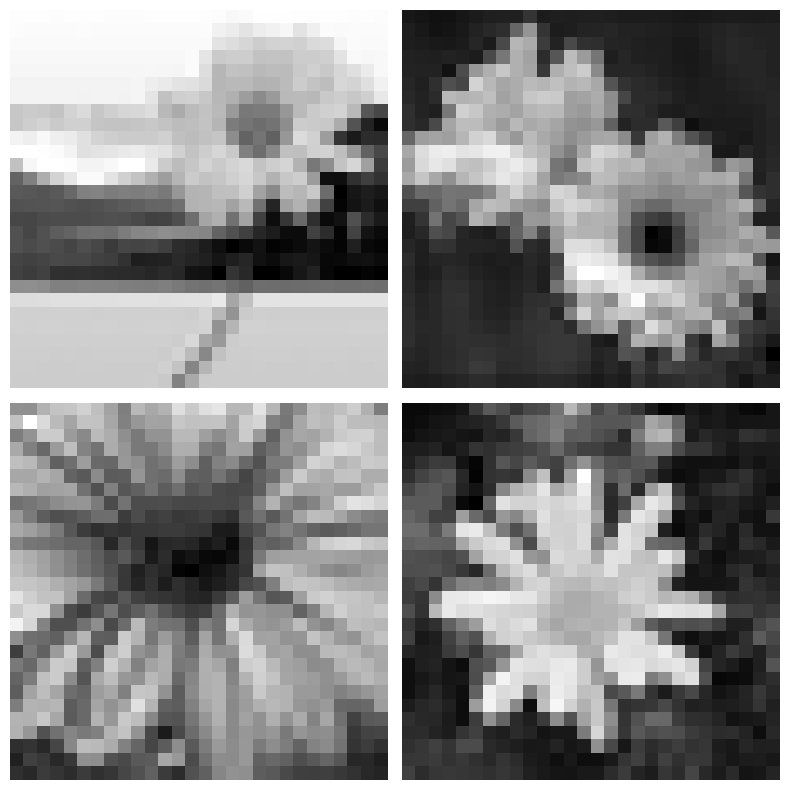

In [8]:
import matplotlib.pyplot as plt

# Assuming Y is defined and contains images
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # Create a 2x2 grid

# Display the images
for i, ax in enumerate(axes.flat):
    ax.imshow(Y[i].reshape(28, 28), cmap='gray')  # Reshape and plot the image
    ax.axis('off')  # Turn off the axis

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

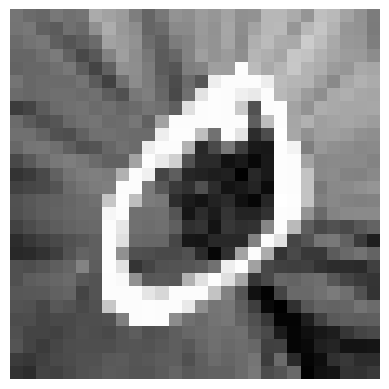

In [9]:
np.random.seed(0)

indices_0 = np.where(y_train == 0)[0]
indices_1 = np.where(y_train == 1)[0]
num_samples_0 = len(indices_0) // 10
num_samples_1 = len(indices_1) // 10
indices_sample_0 = np.random.choice(indices_0, size=num_samples_0, replace=False)
indices_sample_1 = np.random.choice(indices_1, size=num_samples_1, replace=False)
indices_sample = np.concatenate((indices_sample_0, indices_sample_1))
image = x_train[1]
bidx = np.random.choice(natural_images.shape[0])
background_image = natural_images[bidx].reshape(28, 28)
background_image_normalized = (background_image - background_image.min()) / (background_image.max() - background_image.min())
background_image = (background_image_normalized * 255).astype(np.uint8)
plt.imshow(background_image, cmap='gray')
combined_image = np.maximum(image, background_image*0.8)
#combined_image = image  + background_image 
plt.imshow(combined_image, cmap='gray')
plt.axis('off')

# Show the plot
plt.show()

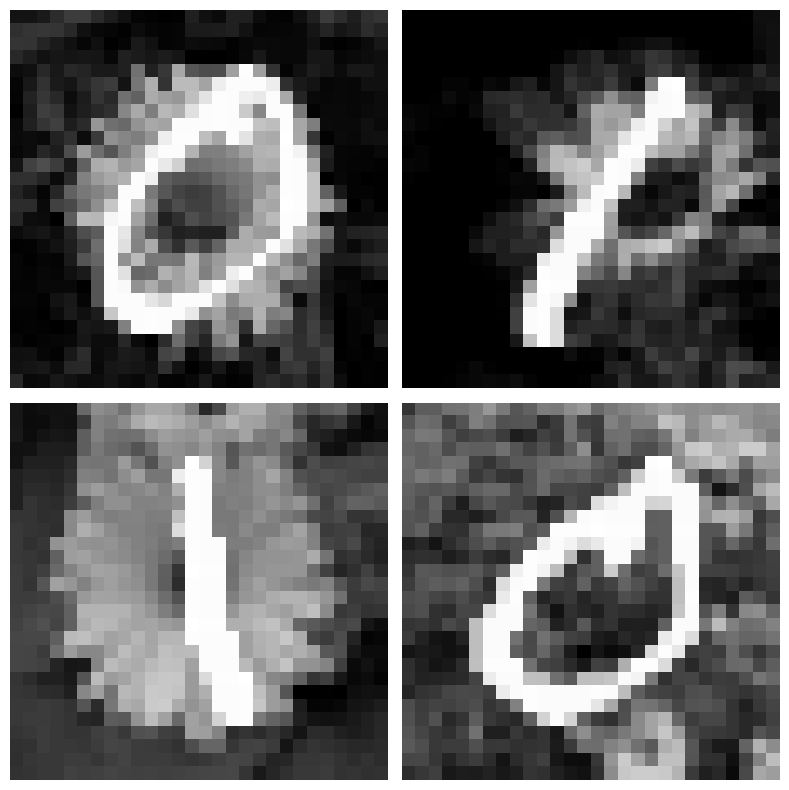

In [10]:
# Assuming x_train and natural_images are already defined
images = [x_train[1], x_train[3], x_train[6], x_train[21]]

# Create a 2x2 grid for the images
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    # Get the i-th image from x_train
    image = images[i]
    
    # Randomly select a background image
    bidx = np.random.choice(natural_images.shape[0])
    background_image = natural_images[bidx].reshape(28, 28)
    
    # Normalize the background image
    background_image_normalized = (background_image - background_image.min()) / (background_image.max() - background_image.min())
    background_image = (background_image_normalized * 255).astype(np.uint8)
    
    # Combine the foreground and background images
    combined_image = np.maximum(image, background_image * 0.8)
    
    # Display the combined image
    ax.imshow(combined_image, cmap='gray')
    ax.axis('off')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [11]:
# Generate the target dataset:
# Load MNIST data
np.random.seed(0)

indices_0 = np.where(y_train == 0)[0]
indices_1 = np.where(y_train == 1)[0]
num_samples_0 = len(indices_0) // 10
num_samples_1 = len(indices_1) // 10
indices_sample_0 = np.random.choice(indices_0, size=num_samples_0, replace=False)
indices_sample_1 = np.random.choice(indices_1, size=num_samples_1, replace=False)
indices_sample = np.concatenate((indices_sample_0, indices_sample_1))

# Initialize a list to hold data for the DataFrame
data = []

# Iterate over all images with label 0 or 3
for doc_idx, idx in enumerate(indices_sample):
    image = x_train[idx]
    bidx = np.random.choice((natural_images.shape[0]//2))
    target_background = natural_images[target_indices]
    background_image = target_background[bidx].reshape(28, 28)
    background_image_normalized = (background_image - background_image.min()) / (background_image.max() - background_image.min())
    background_image = (background_image_normalized * 255).astype(np.uint8)
    combined_image = np.maximum(image, background_image*0.8)
    # Flatten the image and collect non-zero pixels
    flattened_img = combined_image.flatten()
    if doc_idx == 0:
        all_image = flattened_img.reshape(1, -1)
    else:
        all_image = np.vstack((all_image, flattened_img))
X = all_image

In [12]:
X.shape


(1477, 784)

In [14]:
num_samples_0

690

In [15]:
num_samples_1

787

In [13]:
Y.shape

(650, 784)

In [12]:
K = 2
W_nmf_sse, H_nmf_sse, nmf_sse_perf = nmf_sse(X.T, K, niter=200)

Iter: 0 .. MSE: 4018.1050
Iter: 1 .. MSE: 3859.1462
Iter: 2 .. MSE: 3784.3665
Iter: 3 .. MSE: 3732.5938
Iter: 4 .. MSE: 3695.6711
Iter: 5 .. MSE: 3668.6248
Iter: 6 .. MSE: 3648.3115
Iter: 7 .. MSE: 3632.6909
Iter: 8 .. MSE: 3620.3999
Iter: 9 .. MSE: 3610.5044
Iter: 10 .. MSE: 3602.3445
Iter: 11 .. MSE: 3595.4424
Iter: 12 .. MSE: 3589.4375
Iter: 13 .. MSE: 3584.0486
Iter: 14 .. MSE: 3579.0466
Iter: 15 .. MSE: 3574.2329
Iter: 16 .. MSE: 3569.4270
Iter: 17 .. MSE: 3564.4561
Iter: 18 .. MSE: 3559.1460
Iter: 19 .. MSE: 3553.3174
Iter: 20 .. MSE: 3546.7810
Iter: 21 .. MSE: 3539.3396
Iter: 22 .. MSE: 3530.7908
Iter: 23 .. MSE: 3520.9377
Iter: 24 .. MSE: 3509.6035
Iter: 25 .. MSE: 3496.6523
Iter: 26 .. MSE: 3482.0129
Iter: 27 .. MSE: 3465.7075
Iter: 28 .. MSE: 3447.8684
Iter: 29 .. MSE: 3428.7476
Iter: 30 .. MSE: 3408.7063
Iter: 31 .. MSE: 3388.1860
Iter: 32 .. MSE: 3367.6626
Iter: 33 .. MSE: 3347.5962
Iter: 34 .. MSE: 3328.3865
Iter: 35 .. MSE: 3310.3394
Iter: 36 .. MSE: 3293.6543
Iter: 37 ..

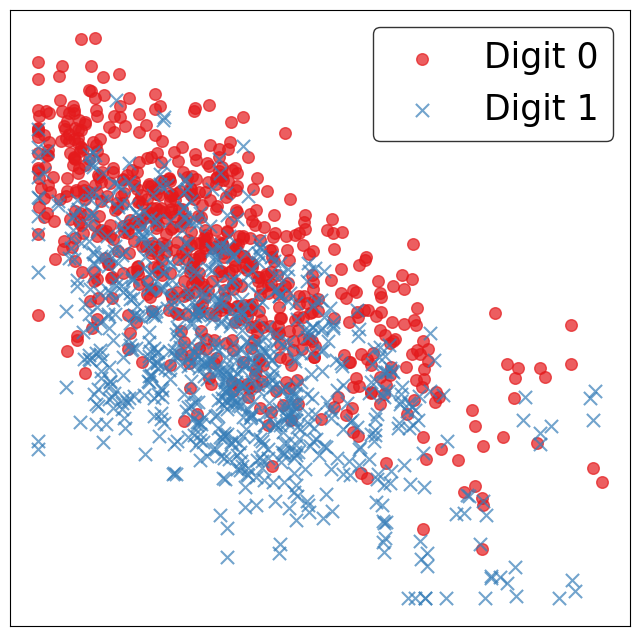

In [13]:
reduced_X = H_nmf_sse.T  # Take the selected rows and transpose for plotting
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) 
labels = np.concatenate((labels_0, labels_1))
# Scatter plot for the target dataset using rows with largest variance
class_0_idx = np.where(np.array(labels) == 0)[0]  # Class 0 (Jogging)
class_1_idx = np.where(np.array(labels) == 1)[0]  # Class 1 (Squatting)

import matplotlib.pyplot as plt

# Define colors for better contrast
colors = ["#E41A1C", "#377EB8"]  # Red for class 0, Blue for class 1 (from ColorBrewer)

plt.figure(figsize=(8, 8))

# Scatter plot with different markers and colors
plt.scatter(reduced_X[class_0_idx, 0], reduced_X[class_0_idx, 1], 
            color=colors[0], alpha=0.7, label="Digit 0", marker='o', s=70)  # Red circle

plt.scatter(reduced_X[class_1_idx, 0], reduced_X[class_1_idx, 1], 
            color=colors[1], alpha=0.7, label="Digit 1", marker='x', s=90)  # Blue cross

# Add titles and labels
#plt.title(f"NMF Scatter Plot", fontsize=16)
#plt.xlabel("Basis 1", fontsize=14)
#plt.ylabel("Basis 2", fontsize=14)
plt.legend(fontsize=25, edgecolor='black')
plt.xticks([]) 
plt.yticks([])
plt.show()

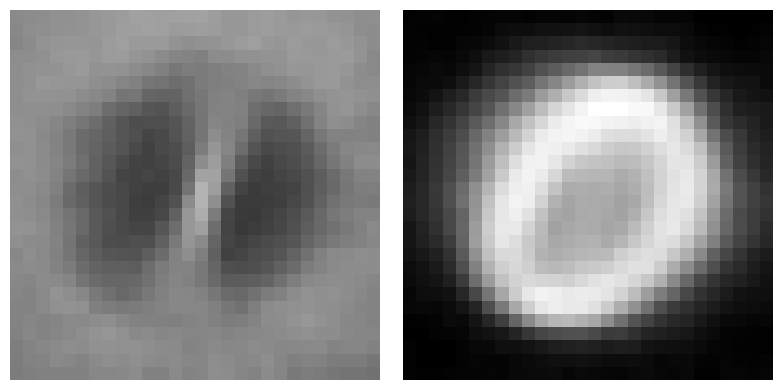

In [14]:
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1, cmap='gray', vmin=0, vmax=255)
#plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2, cmap='gray', vmin=0, vmax=255)
#plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

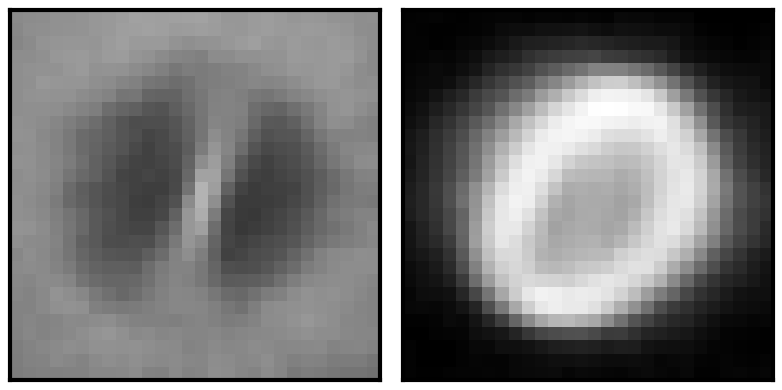

In [15]:
# Plot the two images
plt.figure(figsize=(8, 4))

# First image
ax1 = plt.subplot(1, 2, 1)
plt.imshow(image1, cmap='gray', vmin=0, vmax=255)
# Keep axis for border but remove ticks and labels
ax1.set_xticks([])
ax1.set_yticks([])
# Set border properties
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

# Second image
ax2 = plt.subplot(1, 2, 2)
plt.imshow(image2, cmap='gray', vmin=0, vmax=255)
# Keep axis for border but remove ticks and labels
ax2.set_xticks([])
ax2.set_yticks([])
# Set border properties
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

# Show the images
plt.tight_layout()
plt.show()

In [16]:
K = 2
alpha = 100000
W_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse(X.T, Y.T, K, alpha, niter=500)

Iter: 0 .. MSE: 14421.3613
Iter: 1 .. MSE: 13505.9199
Iter: 2 .. MSE: 13180.5947
Iter: 3 .. MSE: 13203.9287
Iter: 4 .. MSE: 13385.8877
Iter: 5 .. MSE: 13615.7539
Iter: 6 .. MSE: 13840.9062
Iter: 7 .. MSE: 14041.2617
Iter: 8 .. MSE: 14212.1807
Iter: 9 .. MSE: 14355.3008
Iter: 10 .. MSE: 14474.2500
Iter: 11 .. MSE: 14572.8770
Iter: 12 .. MSE: 14654.6553
Iter: 13 .. MSE: 14722.5049
Iter: 14 .. MSE: 14778.8418
Iter: 15 .. MSE: 14825.6641
Iter: 16 .. MSE: 14864.5996
Iter: 17 .. MSE: 14897.0137
Iter: 18 .. MSE: 14924.0137
Iter: 19 .. MSE: 14946.5234
Iter: 20 .. MSE: 14965.3008
Iter: 21 .. MSE: 14980.9707
Iter: 22 .. MSE: 14994.0498
Iter: 23 .. MSE: 15004.9717
Iter: 24 .. MSE: 15014.0977
Iter: 25 .. MSE: 15021.7363
Iter: 26 .. MSE: 15028.1406
Iter: 27 .. MSE: 15033.5332
Iter: 28 .. MSE: 15038.0781
Iter: 29 .. MSE: 15041.9121
Iter: 30 .. MSE: 15045.1367
Iter: 31 .. MSE: 15047.8438
Iter: 32 .. MSE: 15050.0947
Iter: 33 .. MSE: 15051.9502
Iter: 34 .. MSE: 15053.4639
Iter: 35 .. MSE: 15054.6777
It

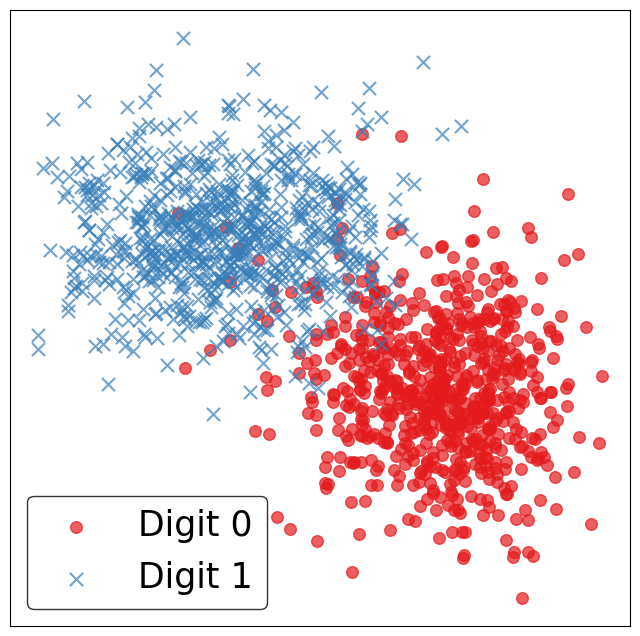

In [17]:
reduced_X = H_X_nmf_sse.T  # Take the selected rows and transpose for plotting
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) 
labels = np.concatenate((labels_0, labels_1))
# Scatter plot for the target dataset using rows with largest variance
class_0_idx = np.where(np.array(labels) == 0)[0]  # Class 0 (Jogging)
class_1_idx = np.where(np.array(labels) == 1)[0]  # Class 1 (Squatting)
# Define colors for better contrast
colors = ["#E41A1C", "#377EB8"]  # Red for class 0, Blue for class 1 (from ColorBrewer)

plt.figure(figsize=(8, 8))

# Scatter plot with different markers and colors
plt.scatter(reduced_X[class_0_idx, 0], reduced_X[class_0_idx, 1], 
            color=colors[0], alpha=0.7, label="Digit 0", marker='o', s=70)  # Red circle

plt.scatter(reduced_X[class_1_idx, 0], reduced_X[class_1_idx, 1], 
            color=colors[1], alpha=0.7, label="Digit 1", marker='x', s=90)  # Blue cross

# Add titles and labels
plt.legend(fontsize=25, edgecolor='black')
plt.xticks([]) 
plt.yticks([])
plt.show()

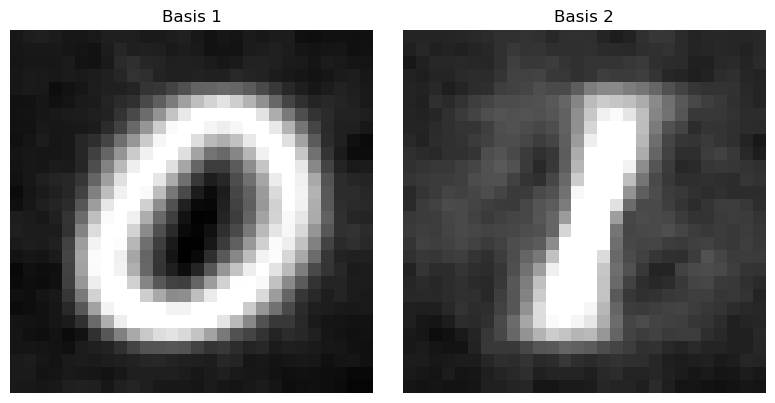

In [18]:
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

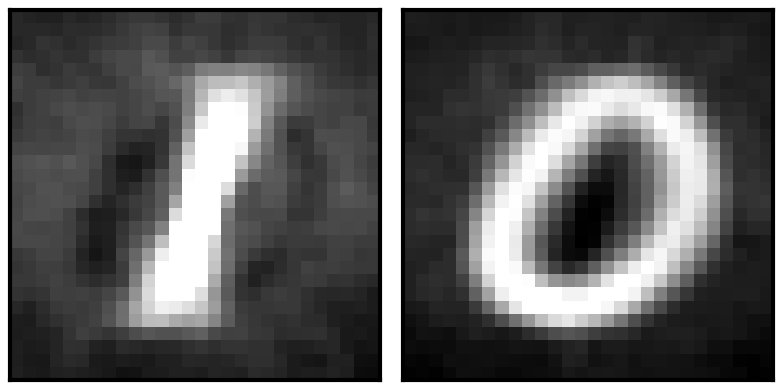

In [44]:
# Plot the two images
plt.figure(figsize=(8, 4))

# First image
ax1 = plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
# Keep axis for border but remove ticks and labels
ax1.set_xticks([])
ax1.set_yticks([])
# Set border properties
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

# Second image
ax2 = plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
# Keep axis for border but remove ticks and labels
ax2.set_xticks([])
ax2.set_yticks([])
# Set border properties
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)

# Show the images
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import torch

def contrastive_nmf_sse_combined_basis(X, Y, K, niter=100):
    """
    Combined basis contrastive NMF with SSE loss objective.
    
    The objective is to minimize:
        J = ||X - (W_s + W_t) H_X||_F^2 + ||Y - W_s H_Y||_F^2,
    where:
        - X is the target data (M x N_X),
        - Y is the background data (M x N_Y),
        - W_s is the shared basis (M x K),
        - W_t is the target-specific basis (M x K),
        - H_X is the target coefficient matrix (K x N_X),
        - H_Y is the background coefficient matrix (K x N_Y).

    The multiplicative update rules are:
        H_X <- H_X * ((W_s+W_t)^T X) / (((W_s+W_t)^T (W_s+W_t)) H_X)
        H_Y <- H_Y * (W_s^T Y) / ((W_s^T W_s) H_Y)
        W_t <- W_t * (X H_X^T) / (((W_s+W_t) H_X H_X^T))
        W_s <- W_s * ((X H_X^T + Y H_Y^T)) / (((W_s+W_t) H_X H_X^T + W_s H_Y H_Y^T))
        
    :param X: numpy array of shape (M, N_X) for target data.
    :param Y: numpy array of shape (M, N_Y) for background data.
    :param K: low rank (number of components for each basis matrix).
    :param niter: number of iterations to run.
    :return: (W_s, W_t, H_X, H_Y, perf)
        - W_s: learned shared basis (M x K).
        - W_t: learned target-specific basis (M x K).
        - H_X: learned target coefficients (K x N_X).
        - H_Y: learned background coefficients (K x N_Y).
        - perf: tensor tracking iteration and reconstruction SSE.
    """
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Get the shapes of the input matrices
    M_X, N_X = X.shape
    M_Y, N_Y = Y.shape
    
    # Initialize basis matrices and coefficients with random nonnegative values
    W_s = torch.rand(M_X, K, device=device)
    W_t = torch.rand(M_X, K, device=device)
    H_X = torch.rand(K, N_X, device=device)
    H_Y = torch.rand(K, N_Y, device=device)
    
    # Convert input data to torch tensors and move them to the device
    X = torch.from_numpy(np.array(X, dtype="float32")).to(device)
    Y = torch.from_numpy(np.array(Y, dtype="float32")).to(device)
    
    # Initialize performance tracking array: columns for iteration index and SSE.
    perf = torch.zeros((niter, 2), dtype=torch.float32, device=device)
    epsilon = 1e-10  # small constant to avoid division by zero

    for i in range(niter):
        # Compute the combined target basis
        W_st = W_s + W_t
        
        # Update H_X:
        #   H_X <- H_X * ((W_s+W_t)^T X) / (((W_s+W_t)^T (W_s+W_t)) H_X)
        numerator = W_st.t() @ X
        denominator = (W_st.t() @ W_st) @ H_X + epsilon
        H_X = H_X * (numerator / denominator)
        
        # Update H_Y:
        #   H_Y <- H_Y * (W_s^T Y) / ((W_s^T W_s) H_Y)
        numerator = W_s.t() @ Y
        denominator = (W_s.t() @ W_s) @ H_Y + epsilon
        H_Y = H_Y * (numerator / denominator)
        
        # Update W_t:
        #   W_t <- W_t * (X H_X^T) / ((W_s+W_t) H_X H_X^T)
        numerator = X @ H_X.t()
        denominator = (W_st @ (H_X @ H_X.t())) + epsilon
        W_t = W_t * (numerator / denominator)
        
        # Update W_s:
        W_st = W_s + W_t
        #   W_s <- W_s * (X H_X^T + Y H_Y^T) / ((W_s+W_t) H_X H_X^T + W_s H_Y H_Y^T)
        numerator = X @ H_X.t() + Y @ H_Y.t()
        denominator = (W_st @ (H_X @ H_X.t())) + (W_s @ (H_Y @ H_Y.t())) + epsilon
        W_s = W_s * (numerator / denominator)
        
        # Compute the reconstruction for target and background data
        reconstruction_X = W_st @ H_X   # Approximation of X using combined basis
        reconstruction_Y = W_s @ H_Y    # Approximation of Y using shared basis
        
        # Compute the sum of squared errors (normalized by matrix sizes)
        sse_X = torch.sum((X - reconstruction_X) ** 2) / (X.size(0) * X.size(1))
        sse_Y = torch.sum((Y - reconstruction_Y) ** 2) / (Y.size(0) * Y.size(1))
        sse = sse_X + sse_Y
        
        # Record the iteration index and SSE
        perf[i, 0] = i
        perf[i, 1] = sse
        
        print(f"Iter: {i} .. MSE: {sse:.4f}")
    
    return (W_s.cpu().numpy(), W_t.cpu().numpy(), 
            H_X.cpu().numpy(), H_Y.cpu().numpy(), perf.cpu())

# Example usage:
# X = np.random.rand(100, 50)
# Y = np.random.rand(100, 30)
# W_s, W_t, H_X, H_Y, perf = contrastive_nmf_sse_combined_basis(X, Y, K=10, niter=100)

In [47]:
K = 2
W_s_nmf_sse, W_t_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse(X.T, Y.T, K, niter=500)

TypeError: contrastive_nmf_sse() missing 1 required positional argument: 'alpha'

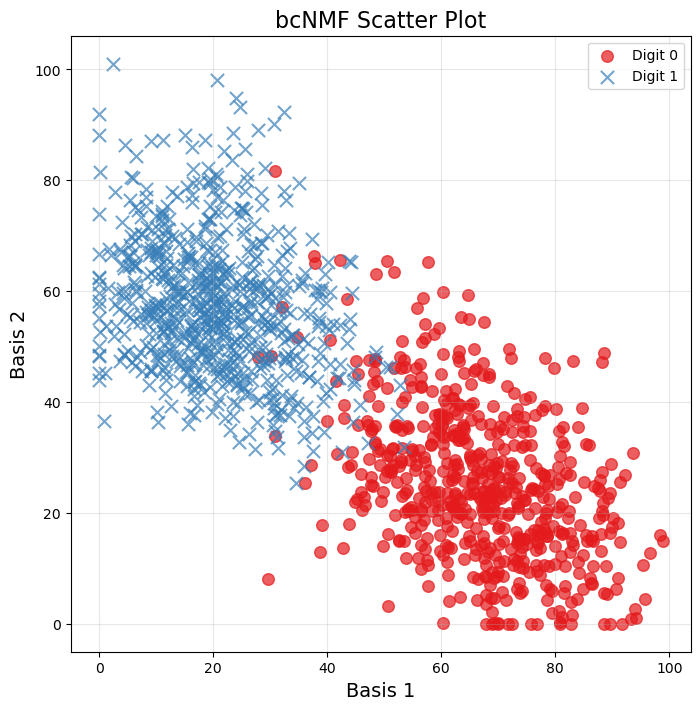

In [17]:
reduced_X = H_X_nmf_sse.T  # Take the selected rows and transpose for plotting
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) 
labels = np.concatenate((labels_0, labels_1))
# Scatter plot for the target dataset using rows with largest variance
class_0_idx = np.where(np.array(labels) == 0)[0]  # Class 0 (Jogging)
class_1_idx = np.where(np.array(labels) == 1)[0]  # Class 1 (Squatting)
# Define colors for better contrast
colors = ["#E41A1C", "#377EB8"]  # Red for class 0, Blue for class 1 (from ColorBrewer)

plt.figure(figsize=(8, 8))

# Scatter plot with different markers and colors
plt.scatter(reduced_X[class_0_idx, 0], reduced_X[class_0_idx, 1], 
            color=colors[0], alpha=0.7, label="Digit 0", marker='o', s=70)  # Red circle

plt.scatter(reduced_X[class_1_idx, 0], reduced_X[class_1_idx, 1], 
            color=colors[1], alpha=0.7, label="Digit 1", marker='x', s=90)  # Blue cross

# Add titles and labels
plt.title(f"bcNMF Scatter Plot", fontsize=16)
plt.xlabel("Basis 1", fontsize=14)
plt.ylabel("Basis 2", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

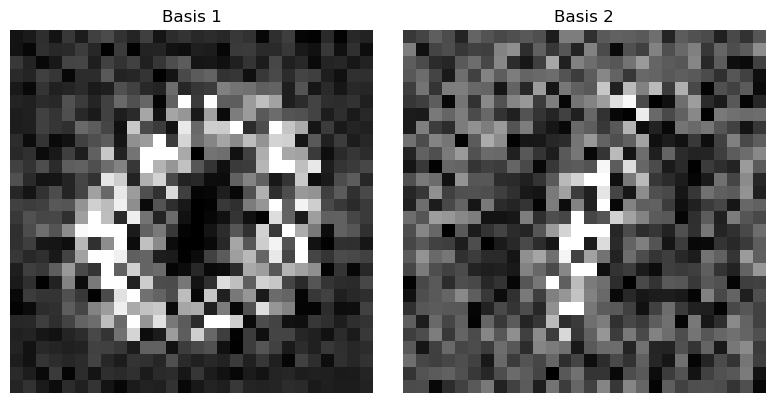

In [18]:
W_nmf_sse = W_s_nmf_sse
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

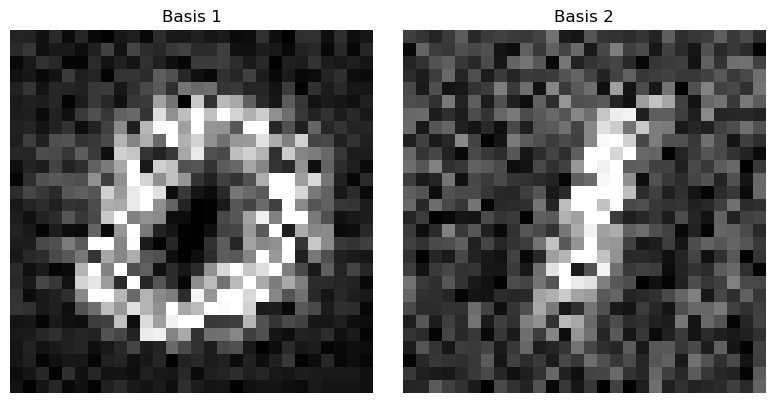

In [19]:
W_nmf_sse = W_t_nmf_sse
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

In [20]:
def contrastive_nmf_sse_combined_basis_reg(X, Y, K, lam, niter=100):
    """
    Combined basis contrastive NMF with SSE loss and orthogonality regularization.
    
    Objective:
        J = ||X - (W_s+W_t) H_X||_F^2 + ||Y - W_s H_Y||_F^2 + lam * ||W_s^T W_t||_F^2,
    where:
        - X is the target data (M x N_X),
        - Y is the background data (M x N_Y),
        - W_s is the shared basis (M x K),
        - W_t is the target-specific basis (M x K),
        - H_X is the target coefficient matrix (K x N_X),
        - H_Y is the background coefficient matrix (K x N_Y).
        
    The multiplicative updates are:
        H_X <- H_X * ((W_s+W_t)^T X) / (((W_s+W_t)^T (W_s+W_t)) H_X)
        H_Y <- H_Y * (W_s^T Y) / ((W_s^T W_s) H_Y)
        W_t <- W_t * (X H_X^T) / ( (W_s+W_t) H_X H_X^T + lam * (W_s (W_s^T W_t)) )
        W_s <- W_s * (X H_X^T + Y H_Y^T) / ( (W_s+W_t) H_X H_X^T + W_s H_Y H_Y^T + lam * (W_t (W_t^T W_s)) )
        
    :param X: numpy array of shape (M, N_X) for target data.
    :param Y: numpy array of shape (M, N_Y) for background data.
    :param K: low rank (number of components for each basis matrix).
    :param lam: regularization parameter lambda.
    :param niter: number of iterations to run.
    :return: (W_s, W_t, H_X, H_Y, perf)
        - W_s: learned shared basis (M x K).
        - W_t: learned target-specific basis (M x K).
        - H_X: learned target coefficients (K x N_X).
        - H_Y: learned background coefficients (K x N_Y).
        - perf: tensor tracking iteration index and reconstruction SSE.
    """
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    M_X, N_X = X.shape
    M_Y, N_Y = Y.shape

    # Initialize basis matrices and coefficients with random nonnegative values
    W_s = torch.rand(M_X, K, device=device)
    W_t = torch.rand(M_X, K, device=device)
    H_X = torch.rand(K, N_X, device=device)
    H_Y = torch.rand(K, N_Y, device=device)
    
    # Convert input data to torch tensors and move them to the device
    X = torch.from_numpy(np.array(X, dtype="float32")).to(device)
    Y = torch.from_numpy(np.array(Y, dtype="float32")).to(device)
    
    # Initialize performance tracking array (iteration index and SSE)
    perf = torch.zeros((niter, 2), dtype=torch.float32, device=device)
    epsilon = 1e-10  # small constant to avoid division by zero

    for i in range(niter):
        # Compute combined target basis: W_st = W_s + W_t
        W_st = W_s + W_t
        
        # Update H_X:
        # H_X <- H_X * ((W_s+W_t)^T X) / (((W_s+W_t)^T (W_s+W_t)) H_X)
        numerator = W_st.t() @ X
        denominator = (W_st.t() @ W_st) @ H_X + epsilon
        H_X = H_X * (numerator / denominator)
        
        # Update H_Y:
        # H_Y <- H_Y * (W_s^T Y) / ((W_s^T W_s) H_Y)
        numerator = W_s.t() @ Y
        denominator = (W_s.t() @ W_s) @ H_Y + epsilon
        H_Y = H_Y * (numerator / denominator)
        
        # Update W_t:
        # W_t <- W_t * (X H_X^T) / ((W_s+W_t) H_X H_X^T + lam * (W_s W_s^T W_t))
        W_st = W_s + W_t
        numerator = X @ H_X.t()
        reg_term_Wt = lam * (W_s @ (W_s.t() @ W_t))
        denominator = (W_st @ (H_X @ H_X.t())) + reg_term_Wt + epsilon
        W_t = W_t * (numerator / denominator)
        
        # Update W_s:
        # W_s <- W_s * (X H_X^T + Y H_Y^T) / ((W_s+W_t) H_X H_X^T + W_s H_Y H_Y^T + lam * (W_t W_t^T W_s))
        W_st = W_s + W_t
        numerator = X @ H_X.t() + Y @ H_Y.t()
        reg_term_Ws = lam * (W_t @ (W_t.t() @ W_s))
        denominator = (W_st @ (H_X @ H_X.t())) + (W_s @ (H_Y @ H_Y.t())) + reg_term_Ws + epsilon
        W_s = W_s * (numerator / denominator)
        
        # Calculate reconstructions
        W_st = W_s + W_t
        reconstruction_X = W_st @ H_X   # Reconstruction of X using combined basis
        reconstruction_Y = W_s @ H_Y    # Reconstruction of Y using shared basis
        
        # Compute sum of squared errors (normalized)
        sse_X = torch.sum((X - reconstruction_X) ** 2) / (X.size(0) * X.size(1))
        sse_Y = torch.sum((Y - reconstruction_Y) ** 2) / (Y.size(0) * Y.size(1))
        sse = sse_X + sse_Y
        
        # Track performance metrics
        perf[i, 0] = i
        perf[i, 1] = sse
        
        print(f"Iter: {i} .. MSE: {sse:.4f}")
    
    return (W_s.cpu().numpy(), W_t.cpu().numpy(), 
            H_X.cpu().numpy(), H_Y.cpu().numpy(), perf.cpu())


In [73]:
K = 2
W_s_nmf_sse, W_t_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse_combined_basis_reg(X.T, Y.T, K, lam=1000000000, niter=500)

Iter: 0 .. MSE: 3383.9922
Iter: 1 .. MSE: 3252.4631
Iter: 2 .. MSE: 3194.0361
Iter: 3 .. MSE: 3153.7930
Iter: 4 .. MSE: 3125.2766
Iter: 5 .. MSE: 3104.5210
Iter: 6 .. MSE: 3089.0256
Iter: 7 .. MSE: 3077.1692
Iter: 8 .. MSE: 3067.8738
Iter: 9 .. MSE: 3060.4009
Iter: 10 .. MSE: 3054.2285
Iter: 11 .. MSE: 3048.9751
Iter: 12 .. MSE: 3044.3501
Iter: 13 .. MSE: 3040.1194
Iter: 14 .. MSE: 3036.0854
Iter: 15 .. MSE: 3032.0679
Iter: 16 .. MSE: 3027.8921
Iter: 17 .. MSE: 3023.3792
Iter: 18 .. MSE: 3018.3403
Iter: 19 .. MSE: 3012.5698
Iter: 20 .. MSE: 3005.8459
Iter: 21 .. MSE: 2997.9355
Iter: 22 .. MSE: 2988.6050
Iter: 23 .. MSE: 2977.6377
Iter: 24 .. MSE: 2964.8657
Iter: 25 .. MSE: 2950.2007
Iter: 26 .. MSE: 2933.6694
Iter: 27 .. MSE: 2915.4355
Iter: 28 .. MSE: 2895.8042
Iter: 29 .. MSE: 2875.2000
Iter: 30 .. MSE: 2854.1208
Iter: 31 .. MSE: 2833.0789
Iter: 32 .. MSE: 2812.5413
Iter: 33 .. MSE: 2792.8857
Iter: 34 .. MSE: 2774.3789
Iter: 35 .. MSE: 2757.1807
Iter: 36 .. MSE: 2741.3599
Iter: 37 ..

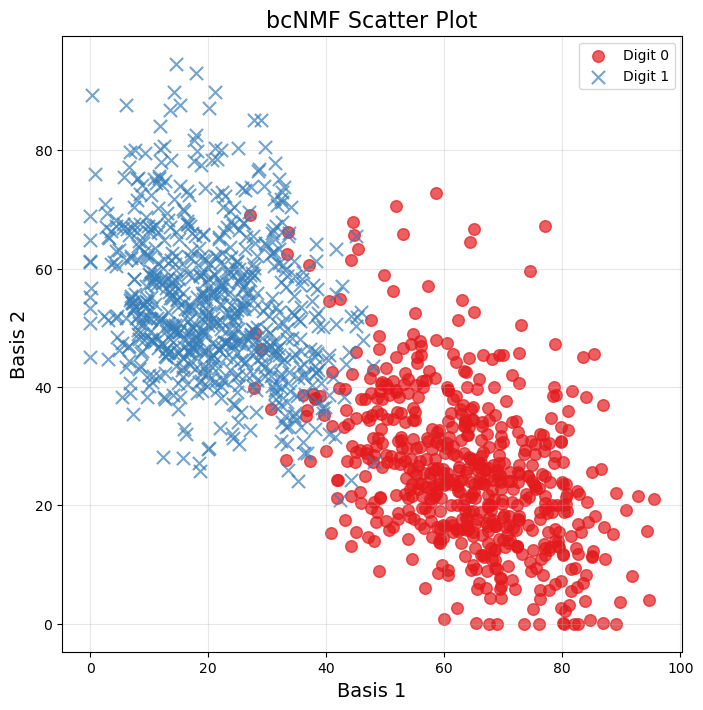

In [74]:
reduced_X = H_X_nmf_sse.T  # Take the selected rows and transpose for plotting
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) 
labels = np.concatenate((labels_0, labels_1))
# Scatter plot for the target dataset using rows with largest variance
class_0_idx = np.where(np.array(labels) == 0)[0]  # Class 0 (Jogging)
class_1_idx = np.where(np.array(labels) == 1)[0]  # Class 1 (Squatting)
# Define colors for better contrast
colors = ["#E41A1C", "#377EB8"]  # Red for class 0, Blue for class 1 (from ColorBrewer)

plt.figure(figsize=(8, 8))

# Scatter plot with different markers and colors
plt.scatter(reduced_X[class_0_idx, 0], reduced_X[class_0_idx, 1], 
            color=colors[0], alpha=0.7, label="Digit 0", marker='o', s=70)  # Red circle

plt.scatter(reduced_X[class_1_idx, 0], reduced_X[class_1_idx, 1], 
            color=colors[1], alpha=0.7, label="Digit 1", marker='x', s=90)  # Blue cross

# Add titles and labels
plt.title(f"bcNMF Scatter Plot", fontsize=16)
plt.xlabel("Basis 1", fontsize=14)
plt.ylabel("Basis 2", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

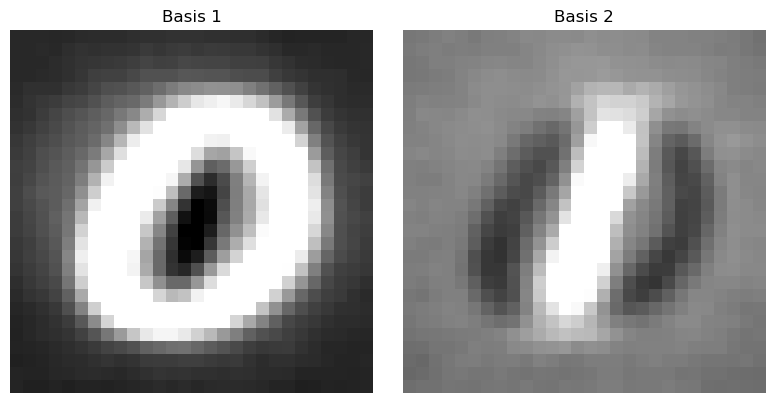

In [75]:
W_nmf_sse = W_s_nmf_sse
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

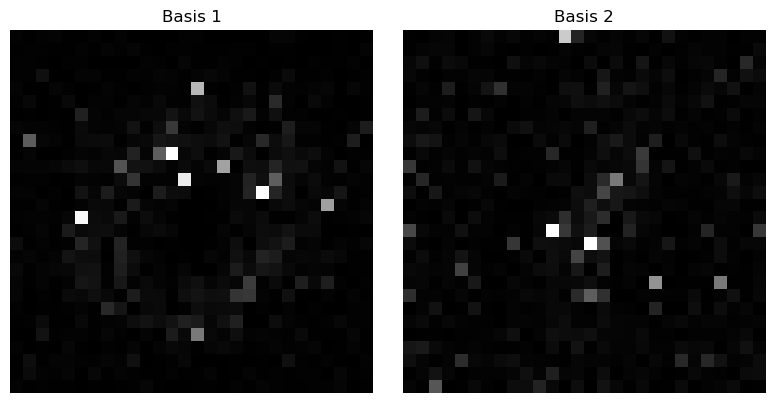

In [76]:
W_nmf_sse = W_t_nmf_sse
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

# Reshape each column into a 28x28 image
image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)

# Plot the two images
plt.figure(figsize=(8, 4))

# First image
plt.subplot(1, 2, 1)
plt.imshow(image1*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 1")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(image2*2, cmap='gray', vmin=0, vmax=255)
plt.title("Basis 2")
plt.axis("off")

# Show the images
plt.tight_layout()
plt.show()

In [177]:
from contrastive import CPCA

mdl = CPCA()
projected_data = mdl.fit_transform(X, Y, plot=False, active_labels=labels, alpha_value=1.6, alpha_selection='manual')

In [178]:
H = projected_data  # Shape (N, K), ensure rows = samples, columns = components
k = len(np.unique(labels))  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)
ari = adjusted_rand_score(labels, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.8569


In [181]:
H = H_X_nmf_sse.T  # Shape (N, K), ensure rows = samples, columns = components
k = len(np.unique(labels))  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)
ari = adjusted_rand_score(labels, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.8628


In [182]:
H = H_nmf_sse.T  # Shape (N, K), ensure rows = samples, columns = components
k = len(np.unique(labels))  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)
ari = adjusted_rand_score(labels, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.0298


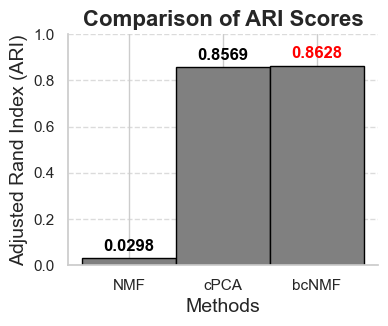

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods_1 = ['NMF', 'cPCA', 'bcNMF']
ari_scores_1 = [0.0298, 0.8569, 0.8628]

# Plotting
plt.figure(figsize=(4, 3))
bars = plt.bar(methods, ari_scores, color='gray', edgecolor='black', width=1.0)  # Same color, no gap between bars

# Add ARI values above bars, highlight the highest value in red
for bar in bars:
    height = bar.get_height()
    color = 'red' if height == max(ari_scores) else 'black'
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color=color)

# Formatting
plt.title('Comparison of ARI Scores', fontsize=16, fontweight='bold')
plt.xlabel('Methods', fontsize=14)
plt.ylabel('Adjusted Rand Index (ARI)', fontsize=14)
plt.ylim(0, 1)  # Ensures the y-axis goes from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remove top and right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Save the figure in high-resolution
plt.savefig('ARI_Comparison.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

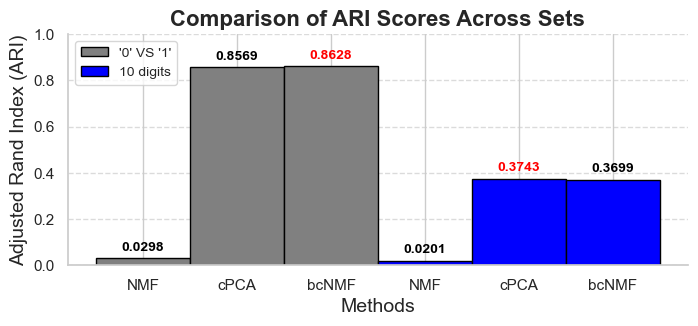

In [397]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods_1 = ['NMF', 'cPCA', 'bcNMF']
ari_scores_1 = [0.0298, 0.8569, 0.8628]

methods_2 = ['NMF', 'cPCA', 'bcNMF']
ari_scores_2 = [0.0201, 0.3743, 0.3699]

# Combine the two datasets for grouped bar positions
x_1 = np.arange(len(methods_1))  # Positions for the first set
x_2 = x_1 + len(methods_1)  # Shift positions for the second set

# Plotting
plt.figure(figsize=(8, 3))  # Adjust figure size
bars_1 = plt.bar(x_1, ari_scores_1, color='gray', edgecolor='black', width=1.0, label="'0' VS '1'")
bars_2 = plt.bar(x_2, ari_scores_2, color='blue', edgecolor='black', width=1.0, label='10 digits')  # Different color for Set 2

# Add ARI values above bars for the first set
for bar in bars_1:
    height = bar.get_height()
    color = 'red' if height == max(ari_scores_1) else 'black'
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Add ARI values above bars for the second set
for bar in bars_2:
    height = bar.get_height()
    color = 'red' if height == max(ari_scores_2) else 'black'
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Formatting
plt.title('Comparison of ARI Scores Across Sets', fontsize=16, fontweight='bold')
plt.xlabel('Methods', fontsize=14)
plt.ylabel('Adjusted Rand Index (ARI)', fontsize=14)
plt.ylim(0, 1)  # Ensures the y-axis goes from 0 to 1
plt.xticks(np.concatenate([x_1, x_2]), methods_1 + methods_2)  # Set x-ticks for both datasets
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend
plt.legend(loc='upper left', fontsize=10)

# Remove top and right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Save the figure in high-resolution
plt.savefig('ARI_Comparison_Grouped.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

## Experiment for the 10 digits

In [76]:
# Generate the background dataset
num_images = 1205*5

# Initialize a list to hold data for the DataFrame
data = []

for doc_idx in range(num_images):
    # Initialize a 28x28 image with zeros
    image = np.zeros((28, 28), dtype=np.uint8)
    
    # Randomly choose 'circle' or 'square'
    shape = np.random.choice(['circle', 'square'])
    
    # Randomly choose center position: center +/- 3 pixels
    center_x = 14 + np.random.randint(-2, 3)
    center_y = 14 + np.random.randint(-2, 3)
    
    # Randomly choose size between 23 and 26 pixels
    size = np.random.randint(22, 26)
    
    # Randomly choose border width of 1 or 2 pixels
    border_width = np.random.randint(1, 3)
    
    if shape == 'square':
        # Calculate half of the inner side length
        half_inner_size = size // 2
        half_outer_size = half_inner_size + border_width

        # Calculate start and end positions, ensuring they are within image bounds
        start_x = max(0, center_x - half_outer_size)
        end_x = min(28, center_x + half_outer_size)
        start_y = max(0, center_y - half_outer_size)
        end_y = min(28, center_y + half_outer_size)

        # Draw the outer square
        for y in range(start_y, end_y):
            for x in range(start_x, end_x):
                # Calculate distance from the inner square boundaries
                dist_x = min(abs(x - (center_x - half_inner_size)), abs(x - (center_x + half_inner_size - 1)))
                dist_y = min(abs(y - (center_y - half_inner_size)), abs(y - (center_y + half_inner_size - 1)))

                # Set pixels for the border
                if dist_x < border_width or dist_y < border_width:
                    image[y, x] = 255

    elif shape == 'circle':
        # Calculate radius
        radius_outer = size / 2
        radius_inner = radius_outer - border_width

        # Create coordinate grids
        y_grid, x_grid = np.ogrid[:28, :28]
        # Calculate distance from center for each pixel
        distance = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)

        # Create a mask for the circular ring (border)
        mask = np.logical_and(distance >= radius_inner, distance <= radius_outer)
        image[mask] = 255

    # Flatten the image and collect non-zero pixels
    flattened_img = image.flatten()
    if doc_idx == 0:
        all_image = flattened_img.reshape(1, -1)
    else:
        all_image = np.vstack((all_image, flattened_img))

Y = all_image

In [78]:
# Generate the target dataset:
# Load MNIST data

indices_0 = np.where(y_train == 0)[0]
indices_1 = np.where(y_train == 1)[0]
indices_2 = np.where(y_train == 2)[0]
indices_3 = np.where(y_train == 3)[0]
indices_4 = np.where(y_train == 4)[0]
indices_5 = np.where(y_train == 5)[0]
indices_6 = np.where(y_train == 6)[0]
indices_7 = np.where(y_train == 7)[0]
indices_8 = np.where(y_train == 8)[0]
indices_9 = np.where(y_train == 9)[0]
num_samples_0 = len(indices_0) // 10
num_samples_1 = len(indices_1) // 10
num_samples_2 = len(indices_2) // 10
num_samples_3 = len(indices_3) // 10
num_samples_4 = len(indices_4) // 10
num_samples_5 = len(indices_5) // 10
num_samples_6 = len(indices_6) // 10
num_samples_7 = len(indices_7) // 10
num_samples_8 = len(indices_8) // 10
num_samples_9 = len(indices_9) // 10
indices_sample_0 = np.random.choice(indices_0, size=num_samples_0, replace=False)
indices_sample_1 = np.random.choice(indices_1, size=num_samples_1, replace=False)
indices_sample_2 = np.random.choice(indices_2, size=num_samples_2, replace=False)
indices_sample_3 = np.random.choice(indices_3, size=num_samples_3, replace=False)
indices_sample_4 = np.random.choice(indices_5, size=num_samples_5, replace=False)
indices_sample_5 = np.random.choice(indices_5, size=num_samples_5, replace=False)
indices_sample_6 = np.random.choice(indices_6, size=num_samples_6, replace=False)
indices_sample_7 = np.random.choice(indices_7, size=num_samples_7, replace=False)
indices_sample_8 = np.random.choice(indices_8, size=num_samples_8, replace=False)
indices_sample_9 = np.random.choice(indices_9, size=num_samples_9, replace=False)
indices_sample = np.concatenate((indices_sample_0, indices_sample_1, indices_sample_2, indices_sample_3, indices_sample_4, indices_sample_5, indices_sample_6, indices_sample_7, indices_sample_8, indices_sample_9))

# Initialize a list to hold data for the DataFrame
data = []

# Iterate over all images with label 0 or 3
for doc_idx, idx in enumerate(indices_sample):
    image = x_train[idx]
    
    # Generate a random shape (circle or square)
    shape_image = np.zeros((28, 28), dtype=np.uint8)
    
    # Randomly choose 'circle' or 'square'
    shape = np.random.choice(['circle', 'square'])
    
    # Randomly choose center position: center +/- 3 pixels
    center_x = 14 + np.random.randint(-2, 3)
    center_y = 14 + np.random.randint(-2, 3)
    
    # Randomly choose size between 23 and 26 pixels
    size = np.random.randint(22, 26)
    
    # Randomly choose border width of 1 or 2 pixels
    border_width = np.random.randint(1, 3)
    
    if shape == 'square':
        # Calculate half of the inner side length
        half_inner_size = size // 2
        half_outer_size = half_inner_size + border_width

        # Calculate start and end positions, ensuring they are within image bounds
        start_x = max(0, center_x - half_outer_size)
        end_x = min(28, center_x + half_outer_size)
        start_y = max(0, center_y - half_outer_size)
        end_y = min(28, center_y + half_outer_size)

        # Draw the outer square
        for y in range(start_y, end_y):
            for x in range(start_x, end_x):
                # Calculate distance from the inner square boundaries
                dist_x = min(abs(x - (center_x - half_inner_size)), abs(x - (center_x + half_inner_size - 1)))
                dist_y = min(abs(y - (center_y - half_inner_size)), abs(y - (center_y + half_inner_size - 1)))

                # Set pixels for the border
                if dist_x < border_width or dist_y < border_width:
                    shape_image[y, x] = 255

    elif shape == 'circle':
        # Calculate radius
        radius_outer = size / 2
        radius_inner = radius_outer - border_width

        # Create coordinate grids
        y_grid, x_grid = np.ogrid[:28, :28]
        # Calculate distance from center for each pixel
        distance = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)

        # Create a mask for the circular ring (border)
        mask = np.logical_and(distance >= radius_inner, distance <= radius_outer)
        shape_image[mask] = 255

    # Overlay the shape on the MNIST image
    # For overlapping pixels, take max(pixel values)
    combined_image = np.maximum(image, shape_image)
    
    # Flatten the image and collect non-zero pixels
    flattened_img = combined_image.flatten()
    if doc_idx == 0:
        all_image = flattened_img.reshape(1, -1)
    else:
        all_image = np.vstack((all_image, flattened_img))

In [ ]:
# Generate the target dataset:
# Load MNIST data
np.random.seed(0)

indices_0 = np.where(y_train == 0)[0]
indices_1 = np.where(y_train == 1)[0]
indices_2 = np.where(y_train == 2)[0]
indices_3 = np.where(y_train == 3)[0]
indices_4 = np.where(y_train == 4)[0]
indices_5 = np.where(y_train == 5)[0]
indices_6 = np.where(y_train == 6)[0]
indices_7 = np.where(y_train == 7)[0]
indices_8 = np.where(y_train == 8)[0]
indices_9 = np.where(y_train == 9)[0]
num_samples_0 = len(indices_0) // 10
num_samples_1 = len(indices_1) // 10
num_samples_2 = len(indices_2) // 10
num_samples_3 = len(indices_3) // 10
num_samples_4 = len(indices_4) // 10
num_samples_5 = len(indices_5) // 10
num_samples_6 = len(indices_6) // 10
num_samples_7 = len(indices_7) // 10
num_samples_8 = len(indices_8) // 10
num_samples_9 = len(indices_9) // 10
indices_sample_0 = np.random.choice(indices_0, size=num_samples_0, replace=False)
indices_sample_1 = np.random.choice(indices_1, size=num_samples_1, replace=False)
indices_sample_2 = np.random.choice(indices_2, size=num_samples_2, replace=False)
indices_sample_3 = np.random.choice(indices_3, size=num_samples_3, replace=False)
indices_sample_4 = np.random.choice(indices_5, size=num_samples_5, replace=False)
indices_sample_5 = np.random.choice(indices_5, size=num_samples_5, replace=False)
indices_sample_6 = np.random.choice(indices_6, size=num_samples_6, replace=False)
indices_sample_7 = np.random.choice(indices_7, size=num_samples_7, replace=False)
indices_sample_8 = np.random.choice(indices_8, size=num_samples_8, replace=False)
indices_sample_9 = np.random.choice(indices_9, size=num_samples_9, replace=False)
indices_sample = np.concatenate((indices_sample_0, indices_sample_1, indices_sample_2, indices_sample_3, indices_sample_4, indices_sample_5, indices_sample_6, indices_sample_7, indices_sample_8, indices_sample_9))

# Initialize a list to hold data for the DataFrame
data = []

# Iterate over all images with label 0 or 3
for doc_idx, idx in enumerate(indices_sample):
    image = x_train[idx]
    bidx = np.random.choice((natural_images.shape[0]//2))
    target_background = natural_images[target_indices]
    background_image = target_background[bidx].reshape(28, 28)
    background_image_normalized = (background_image - background_image.min()) / (background_image.max() - background_image.min())
    background_image = (background_image_normalized * 255).astype(np.uint8)
    combined_image = np.maximum(image, background_image*0.8)
    # Flatten the image and collect non-zero pixels
    flattened_img = combined_image.flatten()
    if doc_idx == 0:
        all_image = flattened_img.reshape(1, -1)
    else:
        all_image = np.vstack((all_image, flattened_img))
X = all_image

In [92]:
X = all_image
K = 16
alpha = 0

W_nmf_sse, H_X_nmf_sse, H_Y_nmf_sse, nmf_sse_perf = contrastive_nmf_sse(X.T, Y.T, K, alpha, niter=500)

Iter: 0 .. MSE: 4162.9014
Iter: 1 .. MSE: 4112.9790
Iter: 2 .. MSE: 4098.7090
Iter: 3 .. MSE: 4079.9204
Iter: 4 .. MSE: 4052.8079
Iter: 5 .. MSE: 4012.1147
Iter: 6 .. MSE: 3950.8054
Iter: 7 .. MSE: 3861.7302
Iter: 8 .. MSE: 3742.7229
Iter: 9 .. MSE: 3602.5886
Iter: 10 .. MSE: 3458.5156
Iter: 11 .. MSE: 3324.6653
Iter: 12 .. MSE: 3206.1924
Iter: 13 .. MSE: 3102.1724
Iter: 14 .. MSE: 3010.0229
Iter: 15 .. MSE: 2927.6848
Iter: 16 .. MSE: 2854.0037
Iter: 17 .. MSE: 2788.4324
Iter: 18 .. MSE: 2730.6423
Iter: 19 .. MSE: 2680.2302
Iter: 20 .. MSE: 2636.5796
Iter: 21 .. MSE: 2598.9050
Iter: 22 .. MSE: 2566.3713
Iter: 23 .. MSE: 2538.1787
Iter: 24 .. MSE: 2513.6084
Iter: 25 .. MSE: 2492.0464
Iter: 26 .. MSE: 2472.9849
Iter: 27 .. MSE: 2456.0195
Iter: 28 .. MSE: 2440.8303
Iter: 29 .. MSE: 2427.1597
Iter: 30 .. MSE: 2414.7964
Iter: 31 .. MSE: 2403.5674
Iter: 32 .. MSE: 2393.3298
Iter: 33 .. MSE: 2383.9636
Iter: 34 .. MSE: 2375.3677
Iter: 35 .. MSE: 2367.4543
Iter: 36 .. MSE: 2360.1472
Iter: 37 ..

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


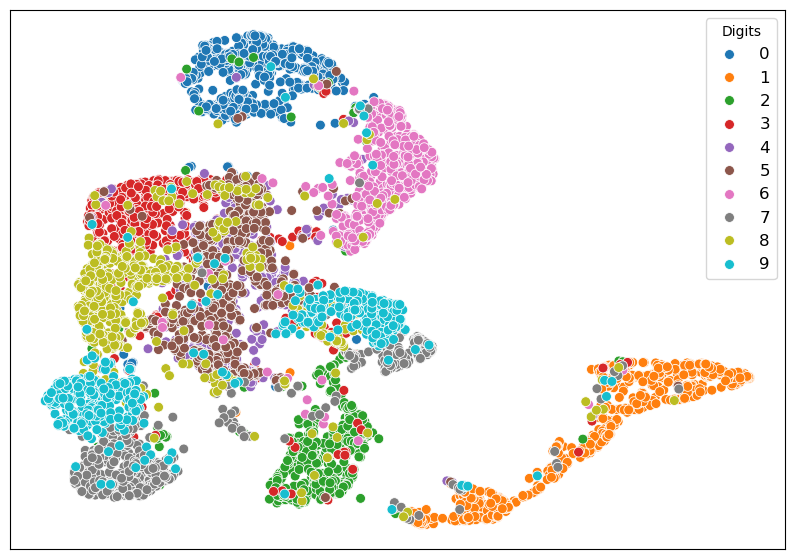

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sns

# Assuming `H_X_nmf_sse` is available as a NumPy array or a tensor
# Convert to NumPy array if it's a tensor
if not isinstance(H_X_nmf_sse, np.ndarray):
    H_X_nmf_sse = H_X_nmf_sse.detach().cpu().numpy()

# Labels for the dataset (e.g., 0s and 3s)
# Ensure you have labels corresponding to X; use the sampled indices
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) * 1
labels_2 = np.ones(len(indices_sample_2)) * 2
labels_3 = np.ones(len(indices_sample_3)) * 3
labels_4 = np.ones(len(indices_sample_4)) * 4
labels_5 = np.ones(len(indices_sample_5)) * 5
labels_6 = np.ones(len(indices_sample_6)) * 6
labels_7 = np.ones(len(indices_sample_7)) * 7
labels_8 = np.ones(len(indices_sample_8)) * 8
labels_9 = np.ones(len(indices_sample_9)) * 9
labels = np.concatenate((labels_0, labels_1, labels_2, labels_3, labels_4, labels_5, labels_6, labels_7, labels_8, labels_9))
labels = labels.astype(int)
# Perform UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
H_X_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)  # Transpose as features are rows in NMF

# Create the plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=H_X_umap[:, 0],
    y=H_X_umap[:, 1],
    hue=labels,          # Different colors for different labels
    palette="tab10",   # Color palette
    s=50,                # Marker size
    legend="full"        # Show full legend
)

# Add titles and labels
plt.legend(title="Digits", loc="best", fontsize=12)
plt.xticks([])
plt.yticks([])
plt.show()

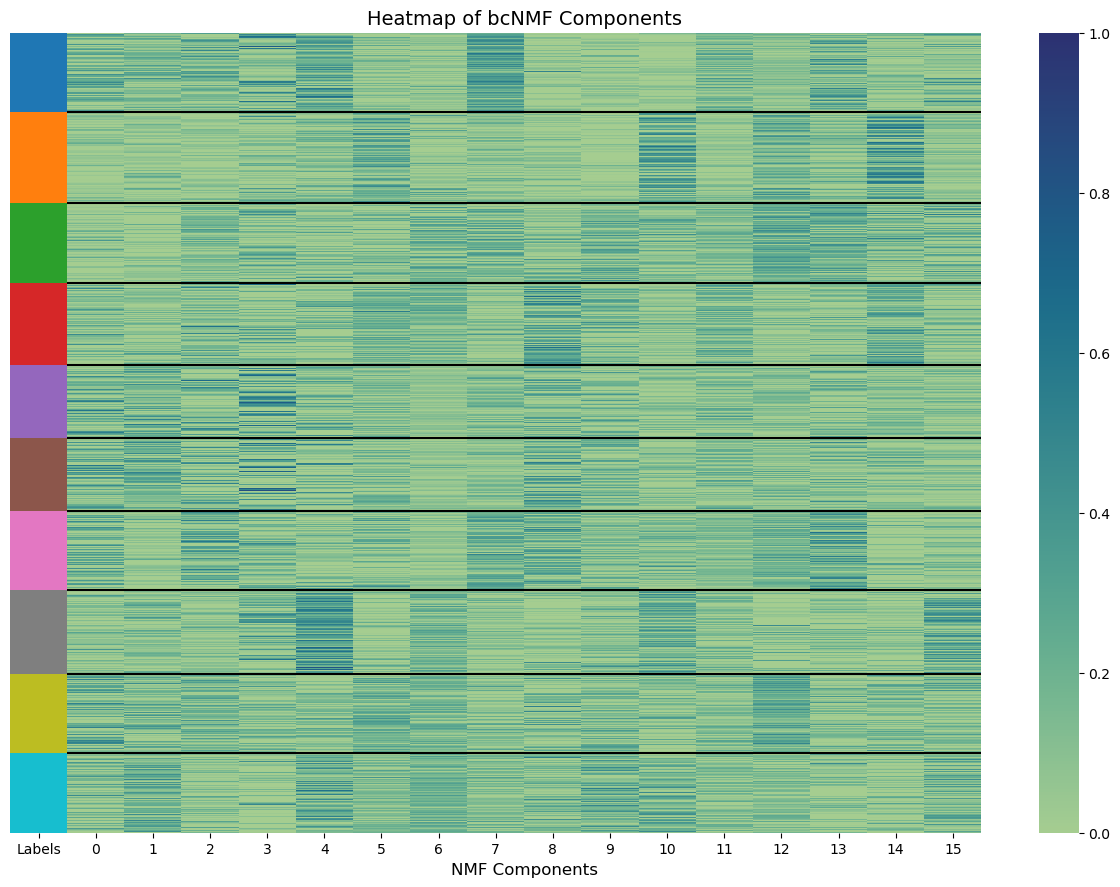

In [64]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Ensure labels are a NumPy array
labels_array = np.array(labels).reshape(-1, 1)

# Normalize H_X_nmf_sse.T for better visualization
H_scaled = H_X_nmf_sse.T / np.max(H_X_nmf_sse.T)  # Normalize between 0 and 1

# Use "crest" as the new colormap
beautiful_cmap = "crest"  # Modern soft blue-green gradient

# Define a colormap for the label column (10 distinct colors)
label_palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))

# Concatenate labels and NMF components, then sort by labels
H_with_labels = np.hstack((labels_array, H_scaled))
H_sorted = H_with_labels[np.argsort(H_with_labels[:, 0])]

# Extract sorted labels and data
sorted_labels = H_sorted[:, 0].reshape(-1, 1)  # Keep label column separate
sorted_data = H_sorted[:, 1:]  # Exclude label column

# Create figure with 2 side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 20], 'wspace': 0})  # Keep no gap

# First heatmap: Label column (sorted)
sns.heatmap(
    sorted_labels, ax=axes[0], cmap=label_palette, annot=False, cbar=False, 
    xticklabels=["Labels"], yticklabels=False
)
axes[0].set_xticklabels(["Labels"], fontsize=10, rotation=0)  # Keep label readable
#axes[0].set_title("Label Column", fontsize=14)

# Second heatmap: H_X_nmf_sse.T with "crest" colormap
sns.heatmap(
    sorted_data, ax=axes[1], cmap=beautiful_cmap, annot=False, cbar=True, 
    xticklabels=True, yticklabels=False
)
axes[1].set_title("Heatmap of bcNMF Components", fontsize=14)
axes[1].set_xlabel("NMF Components", fontsize=12)
#axes[1].set_ylabel("Samples", fontsize=12)

# **Add horizontal separation lines between different labels**
unique_labels = np.unique(sorted_labels)
for label in unique_labels[:-1]:  # Skip last label (no need for extra line)
    last_index = np.where(sorted_labels == label)[0][-1]  # Last row of this label
    axes[1].hlines(y=last_index + 1, xmin=0, xmax=sorted_data.shape[1], colors='black', linewidth=1.5)

# Adjust layout to remove gaps
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

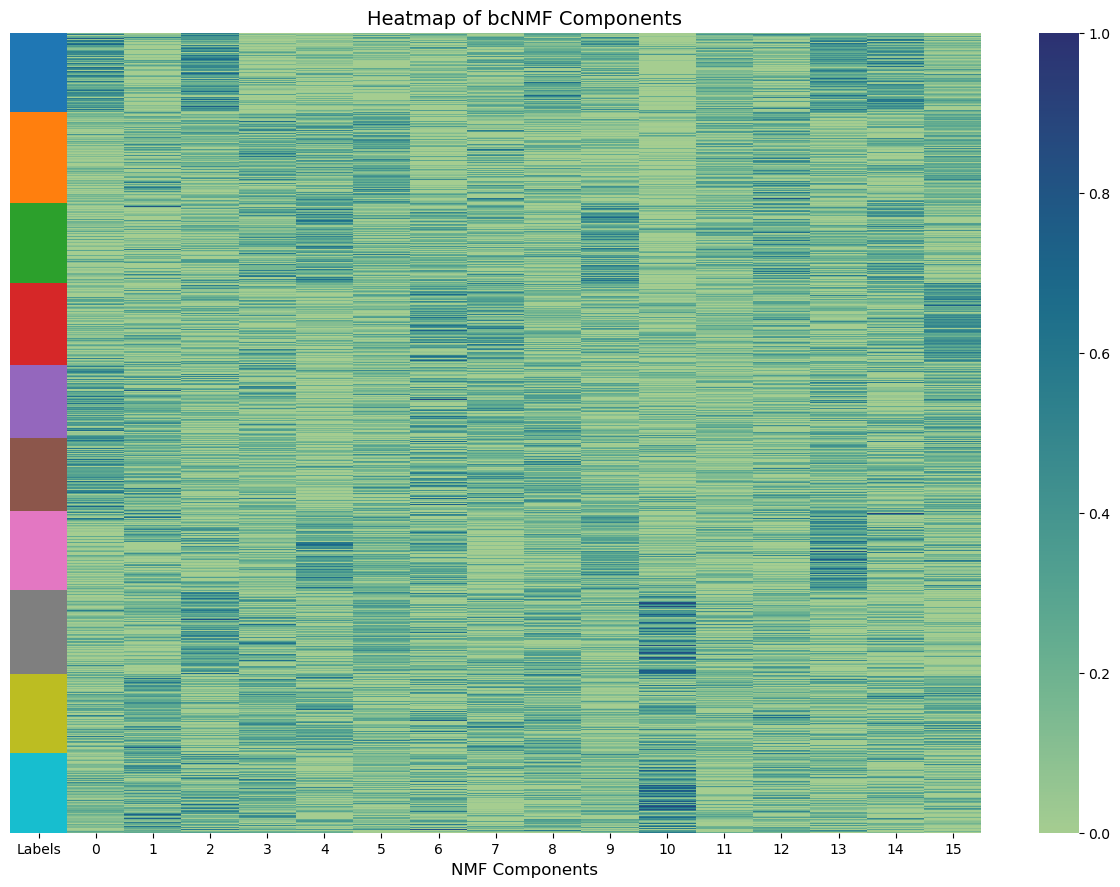

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Ensure labels are a NumPy array
labels_array = np.array(labels).reshape(-1, 1)

# Normalize H_X_nmf_sse.T for better visualization
H_scaled = H_X_nmf_sse.T / np.max(H_X_nmf_sse.T)  # Normalize between 0 and 1

# Define a colormap for the label column (10 distinct colors)
label_palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))

# Concatenate the labels as the first column
H_with_labels = np.hstack((labels_array, H_scaled))

# Create figure with 2 side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 20], 'wspace': 0})  # Ensures labels have same width as one component

# First heatmap: Label column with 10 distinct colors
sns.heatmap(
    labels_array, ax=axes[0], cmap=label_palette, annot=False, cbar=False, 
    xticklabels=["Labels"], yticklabels=False
)
axes[0].set_xticklabels(["Labels"], fontsize=10, rotation=0)  # Keep label readable
#axes[0].set_title("Label Column", fontsize=14)

# Second heatmap: H_X_nmf_sse.T with 0 as no color
sns.heatmap(
    H_scaled, ax=axes[1], cmap="crest", annot=False, cbar=True, 
    xticklabels=True, yticklabels=False
)
axes[1].set_title("Heatmap of bcNMF Components", fontsize=14)
axes[1].set_xlabel("NMF Components", fontsize=12)
#axes[1].set_ylabel("Samples", fontsize=12)

# Adjust layout
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove extra padding
plt.show()

In [88]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score
from scipy.stats import mode

y_true = labels

# NMF factorized matrix H (from earlier code, e.g., H_X_nmf_sse)
H = H_X_nmf_sse.T  # Shape (N, K), ensure rows = samples, columns = components

# 1. Apply K-means Clustering
k = len(np.unique(y_true))  # Number of unique labels (2: for digits 0 and 3)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)

# 2. Map K-means clusters to labels using majority voting
def map_clusters_to_labels(y_true, y_pred):
    """
    Map clusters to ground-truth labels using majority voting.
    """
    labels = np.zeros_like(y_pred)
    for cluster in range(np.max(y_pred) + 1):
        mask = y_pred == cluster
        most_common = mode(y_true[mask])[0]
        labels[mask] = most_common
    return labels

# Map clusters to labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# 3. Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, y_pred_mapped)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.3436


/Users/lyx/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


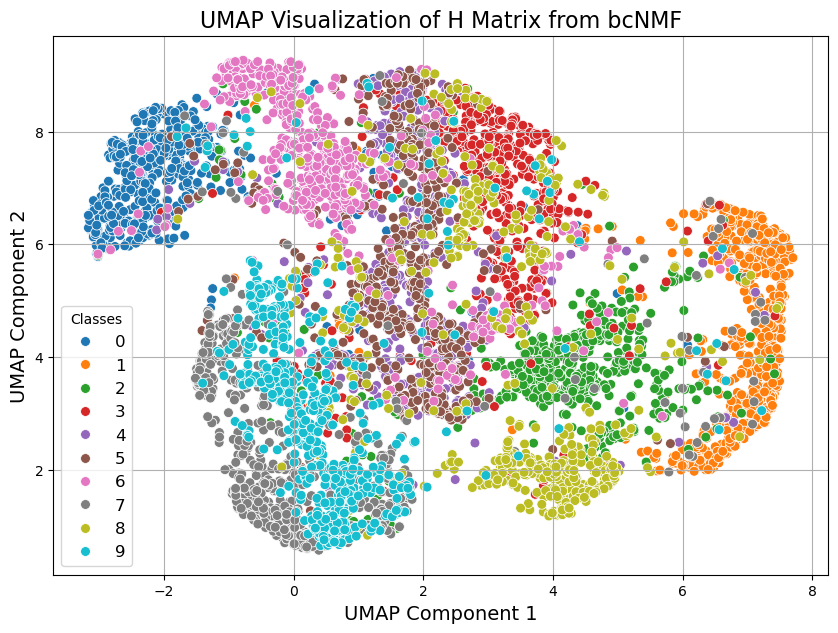

In [60]:
if not isinstance(H_X_nmf_sse, np.ndarray):
    H_X_nmf_sse = H_X_nmf_sse.detach().cpu().numpy()

# Labels for the dataset (e.g., 0s and 3s)
# Ensure you have labels corresponding to X; use the sampled indices
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) * 1
labels_2 = np.ones(len(indices_sample_2)) * 2
labels_3 = np.ones(len(indices_sample_3)) * 3
labels_4 = np.ones(len(indices_sample_4)) * 4
labels_5 = np.ones(len(indices_sample_5)) * 5
labels_6 = np.ones(len(indices_sample_6)) * 6
labels_7 = np.ones(len(indices_sample_7)) * 7
labels_8 = np.ones(len(indices_sample_8)) * 8
labels_9 = np.ones(len(indices_sample_9)) * 9
labels = np.concatenate((labels_0, labels_1, labels_2, labels_3, labels_4, labels_5, labels_6, labels_7, labels_8, labels_9))
labels = labels.astype(int)

# Perform UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
H_X_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)  # Transpose as features are rows in NMF

# Create the plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=H_X_umap[:, 0],
    y=H_X_umap[:, 1],
    hue=labels,          # Different colors for different labels
    palette="tab10",   # Color palette
    s=50,                # Marker size
    legend="full"        # Show full legend
)

# Add titles and labels
plt.title("UMAP Visualization of H Matrix from bcNMF", fontsize=16)
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.legend(title="Classes", loc="best", fontsize=12)
plt.grid(True)
plt.show()

/Users/lyx/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


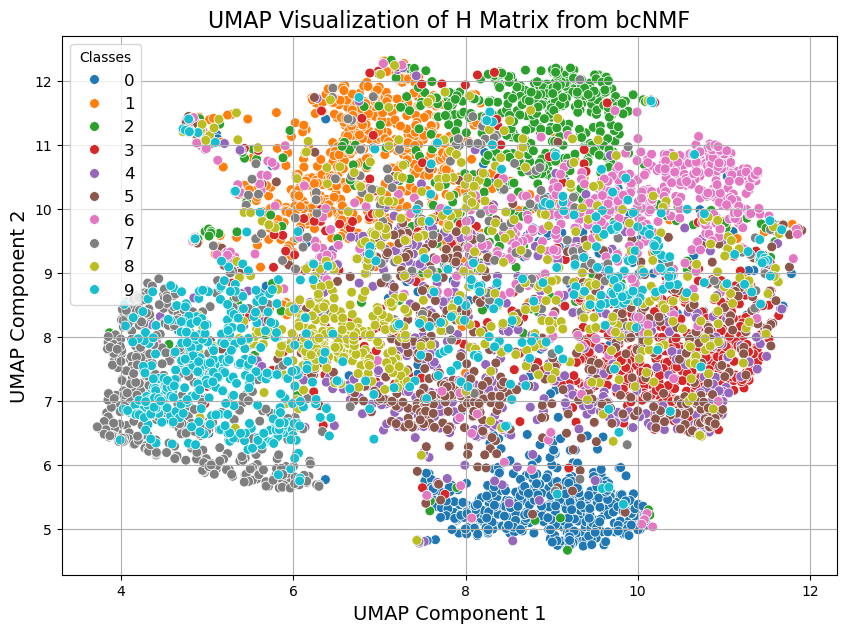

In [30]:
if not isinstance(H_X_nmf_sse, np.ndarray):
    H_X_nmf_sse = H_X_nmf_sse.detach().cpu().numpy()

# Labels for the dataset (e.g., 0s and 3s)
# Ensure you have labels corresponding to X; use the sampled indices
labels_0 = np.zeros(len(indices_sample_0))
labels_1 = np.ones(len(indices_sample_1)) * 1
labels_2 = np.ones(len(indices_sample_2)) * 2
labels_3 = np.ones(len(indices_sample_3)) * 3
labels_4 = np.ones(len(indices_sample_4)) * 4
labels_5 = np.ones(len(indices_sample_5)) * 5
labels_6 = np.ones(len(indices_sample_6)) * 6
labels_7 = np.ones(len(indices_sample_7)) * 7
labels_8 = np.ones(len(indices_sample_8)) * 8
labels_9 = np.ones(len(indices_sample_9)) * 9
labels = np.concatenate((labels_0, labels_1, labels_2, labels_3, labels_4, labels_5, labels_6, labels_7, labels_8, labels_9))
labels = labels.astype(int)

# Perform UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
H_X_umap = umap_reducer.fit_transform(H_X_nmf_sse.T)  # Transpose as features are rows in NMF

# Create the plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=H_X_umap[:, 0],
    y=H_X_umap[:, 1],
    hue=labels,          # Different colors for different labels
    palette="tab10",   # Color palette
    s=50,                # Marker size
    legend="full"        # Show full legend
)

# Add titles and labels
plt.title("UMAP Visualization of H Matrix from bcNMF", fontsize=16)
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.legend(title="Classes", loc="best", fontsize=12)
plt.grid(True)
plt.show()

In [31]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score
from scipy.stats import mode

y_true = labels

# NMF factorized matrix H (from earlier code, e.g., H_X_nmf_sse)
H = H_X_nmf_sse.T  # Shape (N, K), ensure rows = samples, columns = components

# 1. Apply K-means Clustering
k = len(np.unique(y_true))  # Number of unique labels (2: for digits 0 and 3)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)

# 2. Map K-means clusters to labels using majority voting
def map_clusters_to_labels(y_true, y_pred):
    """
    Map clusters to ground-truth labels using majority voting.
    """
    labels = np.zeros_like(y_pred)
    for cluster in range(np.max(y_pred) + 1):
        mask = y_pred == cluster
        most_common = mode(y_true[mask])[0]
        labels[mask] = most_common
    return labels

# Map clusters to labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# 3. Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, y_pred_mapped)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.1933


In [383]:
from contrastive import CPCA

mdl = CPCA(n_components=16)
projected_data = mdl.fit_transform(X, Y, plot=False, active_labels=labels, alpha_value=2.7, alpha_selection='manual')

/Users/lyx/anaconda3/lib/python3.11/site-packages/contrastive/__init__.py:40: RuntimeWarning: invalid value encountered in divide
  standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)


In [384]:
H = projected_data # Shape (N, K), ensure rows = samples, columns = components

# 1. Apply K-means Clustering
k = len(np.unique(y_true))  # Number of unique labels (2: for digits 0 and 3)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)

# 2. Map K-means clusters to labels using majority voting
def map_clusters_to_labels(y_true, y_pred):
    """
    Map clusters to ground-truth labels using majority voting.
    """
    labels = np.zeros_like(y_pred)
    for cluster in range(np.max(y_pred) + 1):
        mask = y_pred == cluster
        most_common = mode(y_true[mask])[0]
        labels[mask] = most_common
    return labels

# Map clusters to labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# 3. Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, y_pred_mapped)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.3743


In [422]:
H = H_X_nmf_sse.T  # Shape (N, K), ensure rows = samples, columns = components

# 1. Apply K-means Clustering
k = len(np.unique(y_true))  # Number of unique labels (2: for digits 0 and 3)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(H)

# 2. Map K-means clusters to labels using majority voting
def map_clusters_to_labels(y_true, y_pred):
    """
    Map clusters to ground-truth labels using majority voting.
    """
    labels = np.zeros_like(y_pred)
    for cluster in range(np.max(y_pred) + 1):
        mask = y_pred == cluster
        most_common = mode(y_true[mask])[0]
        labels[mask] = most_common
    return labels

# Map clusters to labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# 3. Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_true, y_pred_mapped)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.1746


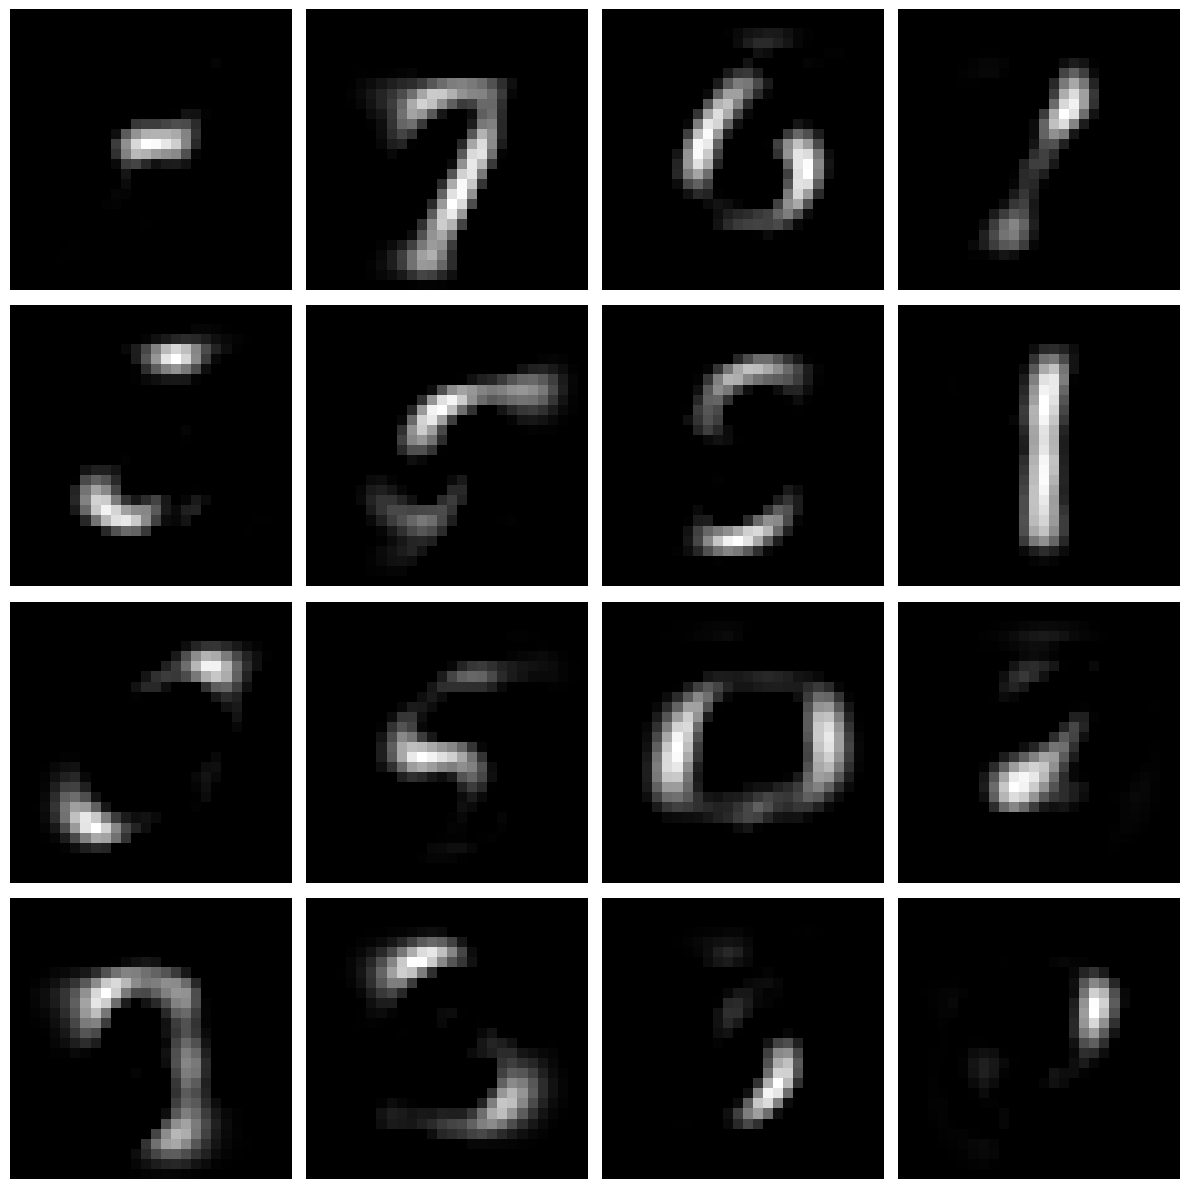

In [94]:
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)
image3 = W_nmf_sse_normalized[:, 2].reshape(28, 28)
image4 = W_nmf_sse_normalized[:, 3].reshape(28, 28)
image5 = W_nmf_sse_normalized[:, 4].reshape(28, 28)
image6 = W_nmf_sse_normalized[:, 5].reshape(28, 28)
image7 = W_nmf_sse_normalized[:, 6].reshape(28, 28)
image8 = W_nmf_sse_normalized[:, 7].reshape(28, 28)
image9 = W_nmf_sse_normalized[:, 8].reshape(28, 28)
image10 = W_nmf_sse_normalized[:, 9].reshape(28, 28)
image11 = W_nmf_sse_normalized[:, 10].reshape(28, 28)
image12 = W_nmf_sse_normalized[:, 11].reshape(28, 28)
image13 = W_nmf_sse_normalized[:, 12].reshape(28, 28)
image14 = W_nmf_sse_normalized[:, 13].reshape(28, 28)
image15 = W_nmf_sse_normalized[:, 14].reshape(28, 28)
image16 = W_nmf_sse_normalized[:, 15].reshape(28, 28)


topic_images = [image1, image2, image3, image4, image5, 
                image6, image7, image8, image9, image10, 
                image11, image12, image13, image14, image15, image16]

# Plot the images in a 4x4 grid
plt.figure(figsize=(12, 12))  # Adjust figure size for a 4x4 grid

for i, topic_image in enumerate(topic_images):
    plt.subplot(4, 4, i + 1)  # Create a subplot in a 4x4 grid
    plt.imshow(topic_image, cmap='gray')  # Display the image
    # plt.title(f'Basis {i + 1}')  # Optional: Set the title
    plt.axis('off')  # Turn off the axis for better visibility

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

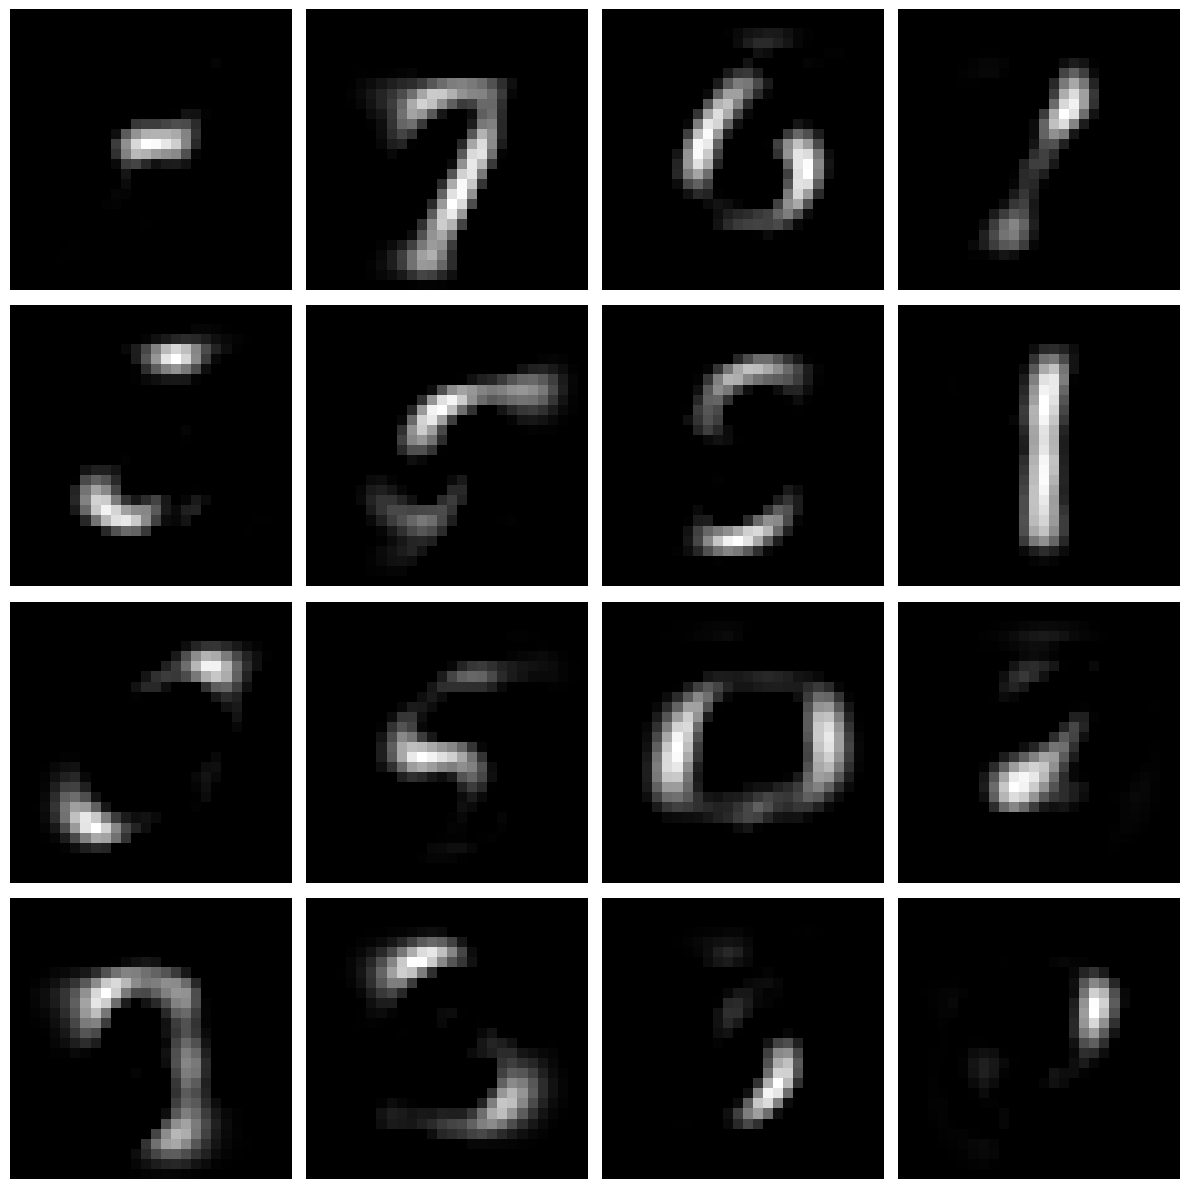

In [95]:
W_nmf_sse_normalized = 255 * (W_nmf_sse - W_nmf_sse.min()) / (W_nmf_sse.max() - W_nmf_sse.min())

image1 = W_nmf_sse_normalized[:, 0].reshape(28, 28)
image2 = W_nmf_sse_normalized[:, 1].reshape(28, 28)
image3 = W_nmf_sse_normalized[:, 2].reshape(28, 28)
image4 = W_nmf_sse_normalized[:, 3].reshape(28, 28)
image5 = W_nmf_sse_normalized[:, 4].reshape(28, 28)
image6 = W_nmf_sse_normalized[:, 5].reshape(28, 28)
image7 = W_nmf_sse_normalized[:, 6].reshape(28, 28)
image8 = W_nmf_sse_normalized[:, 7].reshape(28, 28)
image9 = W_nmf_sse_normalized[:, 8].reshape(28, 28)
image10 = W_nmf_sse_normalized[:, 9].reshape(28, 28)
image11 = W_nmf_sse_normalized[:, 10].reshape(28, 28)
image12 = W_nmf_sse_normalized[:, 11].reshape(28, 28)
image13 = W_nmf_sse_normalized[:, 12].reshape(28, 28)
image14 = W_nmf_sse_normalized[:, 13].reshape(28, 28)
image15 = W_nmf_sse_normalized[:, 14].reshape(28, 28)
image16 = W_nmf_sse_normalized[:, 15].reshape(28, 28)


topic_images = [image1, image2, image3, image4, image5, 
                image6, image7, image8, image9, image10, 
                image11, image12, image13, image14, image15, image16]

# Plot the images in a 4x4 grid
plt.figure(figsize=(12, 12))  # Adjust figure size for a 4x4 grid

for i, topic_image in enumerate(topic_images):
    plt.subplot(4, 4, i + 1)  # Create a subplot in a 4x4 grid
    plt.imshow(topic_image, cmap='gray')  # Display the image
    # plt.title(f'Basis {i + 1}')  # Optional: Set the title
    plt.axis('off')  # Turn off the axis for better visibility

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

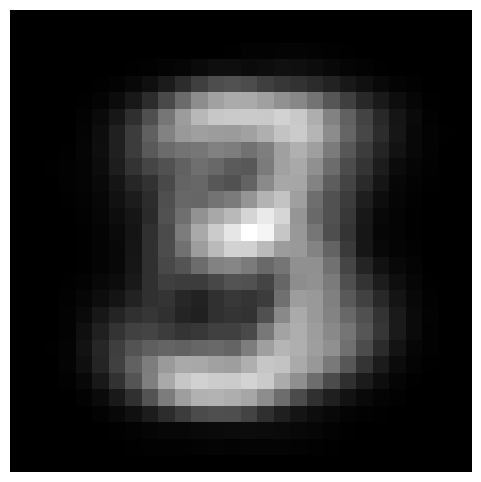

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming H_X_nmf_sse (K x N) and W_nmf_sse (M x K) are defined
# H_X_nmf_sse.T is N x K, where N = number of samples, K = 16 (components)
# W_nmf_sse is 784 x 16 (components)
# labels array corresponds to digits (0 to 9)

# Step 1: Get indices for Digit 0
digit_0_indices = np.where(labels == 3)[0]  # Indices corresponding to Digit 0

# Step 2: Extract coordinates from H_X_nmf_sse for Digit 0
H_digit_0 = H_X_nmf_sse[:, digit_0_indices]  # Shape: (K, number of Digit 0 samples)

# Step 3: Calculate the average weights for Digit 0
average_weights = H_digit_0.mean(axis=1)  # Average across all samples for Digit 0
normalized_weights = average_weights / np.sum(average_weights)  # Normalize to sum to 1

# Step 4: Compute the weighted sum of W
# Weighted sum is a linear combination of the columns of W
weighted_sum_W = W_nmf_sse @ normalized_weights  # Shape: (784,)

# Step 5: Reshape to 28x28 for visualization
weighted_image = weighted_sum_W.reshape(28, 28)

# Step 6: Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(weighted_image, cmap='gray')
#plt.title("Weighted Sum Image for Digit 0")
plt.axis('off')
plt.show()

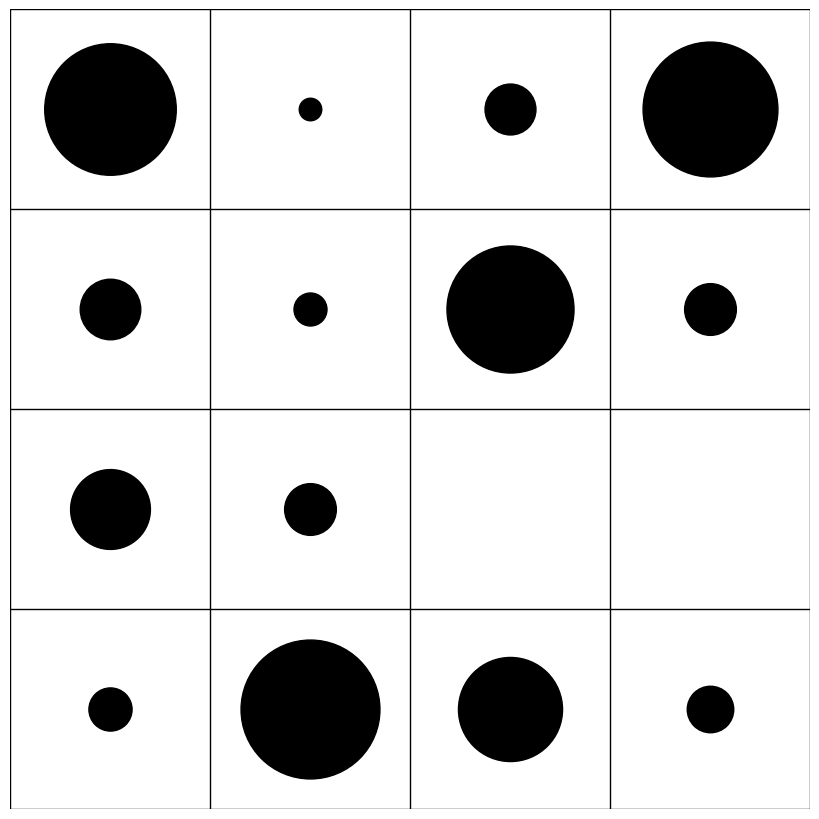

In [111]:
normalized_weights_rescaled = normalized_weights / normalized_weights.max()

# Create a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8), gridspec_kw={'wspace': 0, 'hspace': 0})

# Plot dots in the center of each square
for i, ax in enumerate(axes.flat):
    # Turn off axis
    ax.axis('off')
    
    # Get weight for the current square
    weight = normalized_weights_rescaled[i]
    
    # Add a dot at the center if the weight is significant
    if weight > 0.1:  # Threshold for visibility
        ax.plot(0.5, 0.5, 'ko', markersize=weight * 100)  # Dot size scales with weight
    
    # Add a box to represent the square
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=1))

    # Set limits to ensure no blank spaces
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Adjust layout to remove any additional space
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

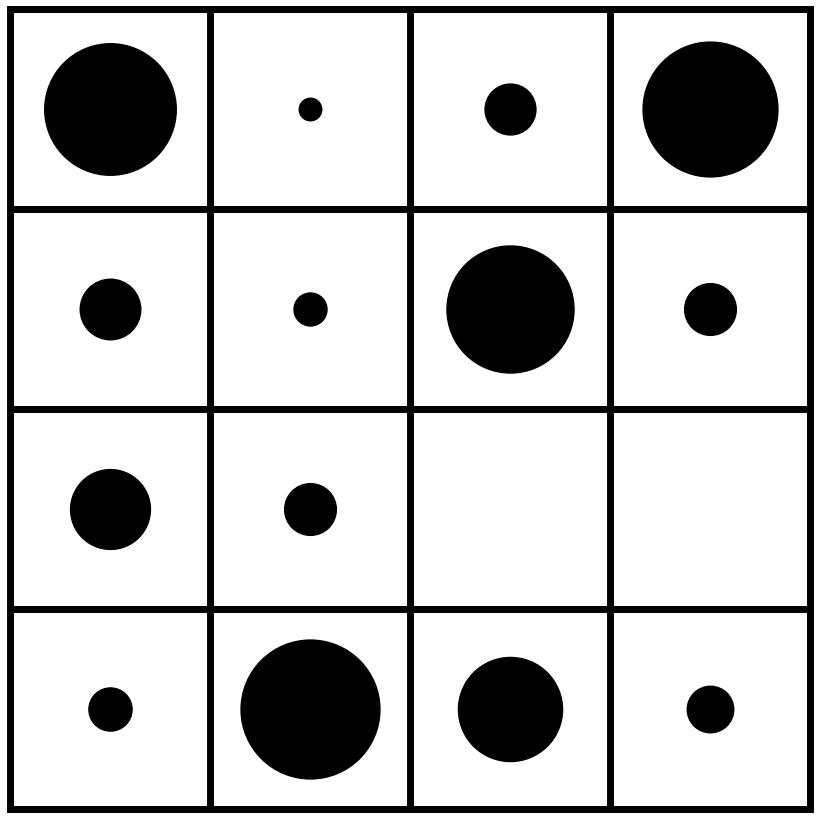

In [112]:
# Create a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8), gridspec_kw={'wspace': 0, 'hspace': 0})

# Plot dots in the center of each square
for i, ax in enumerate(axes.flat):
    # Turn off axis
    ax.axis('off')
    
    # Get weight for the current square
    weight = normalized_weights_rescaled[i]
    
    # Add a dot at the center if the weight is significant
    if weight > 0.1:  # Threshold for visibility
        ax.plot(0.5, 0.5, 'ko', markersize=weight * 100)  # Dot size scales with weight
    
    # Add a box to represent the square with BOLDER border
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=5))
    
    # Set limits to ensure no blank spaces
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Add a bold outer border around the entire figure
fig.add_artist(plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, 
                             fill=False, edgecolor='black', linewidth=5))

# Adjust layout to remove any additional space
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

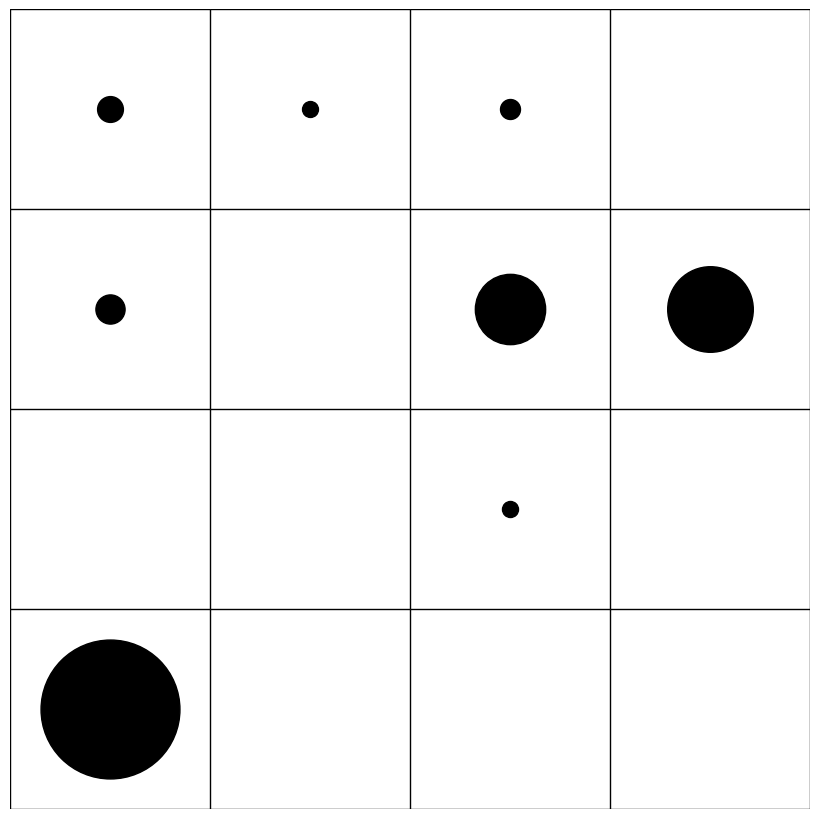

In [95]:
normalized_weights_rescaled = normalized_weights / normalized_weights.max()

# Create a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8), gridspec_kw={'wspace': 0, 'hspace': 0})

# Plot dots in the center of each square
for i, ax in enumerate(axes.flat):
    # Turn off axis
    ax.axis('off')
    
    # Get weight for the current square
    weight = normalized_weights_rescaled[i]
    
    # Add a dot at the center if the weight is significant
    if weight > 0.1:  # Threshold for visibility
        ax.plot(0.5, 0.5, 'ko', markersize=weight * 100)  # Dot size scales with weight
    
    # Add a box to represent the square
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=1))

    # Set limits to ensure no blank spaces
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Adjust layout to remove any additional space
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_94591/2398903603.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16)


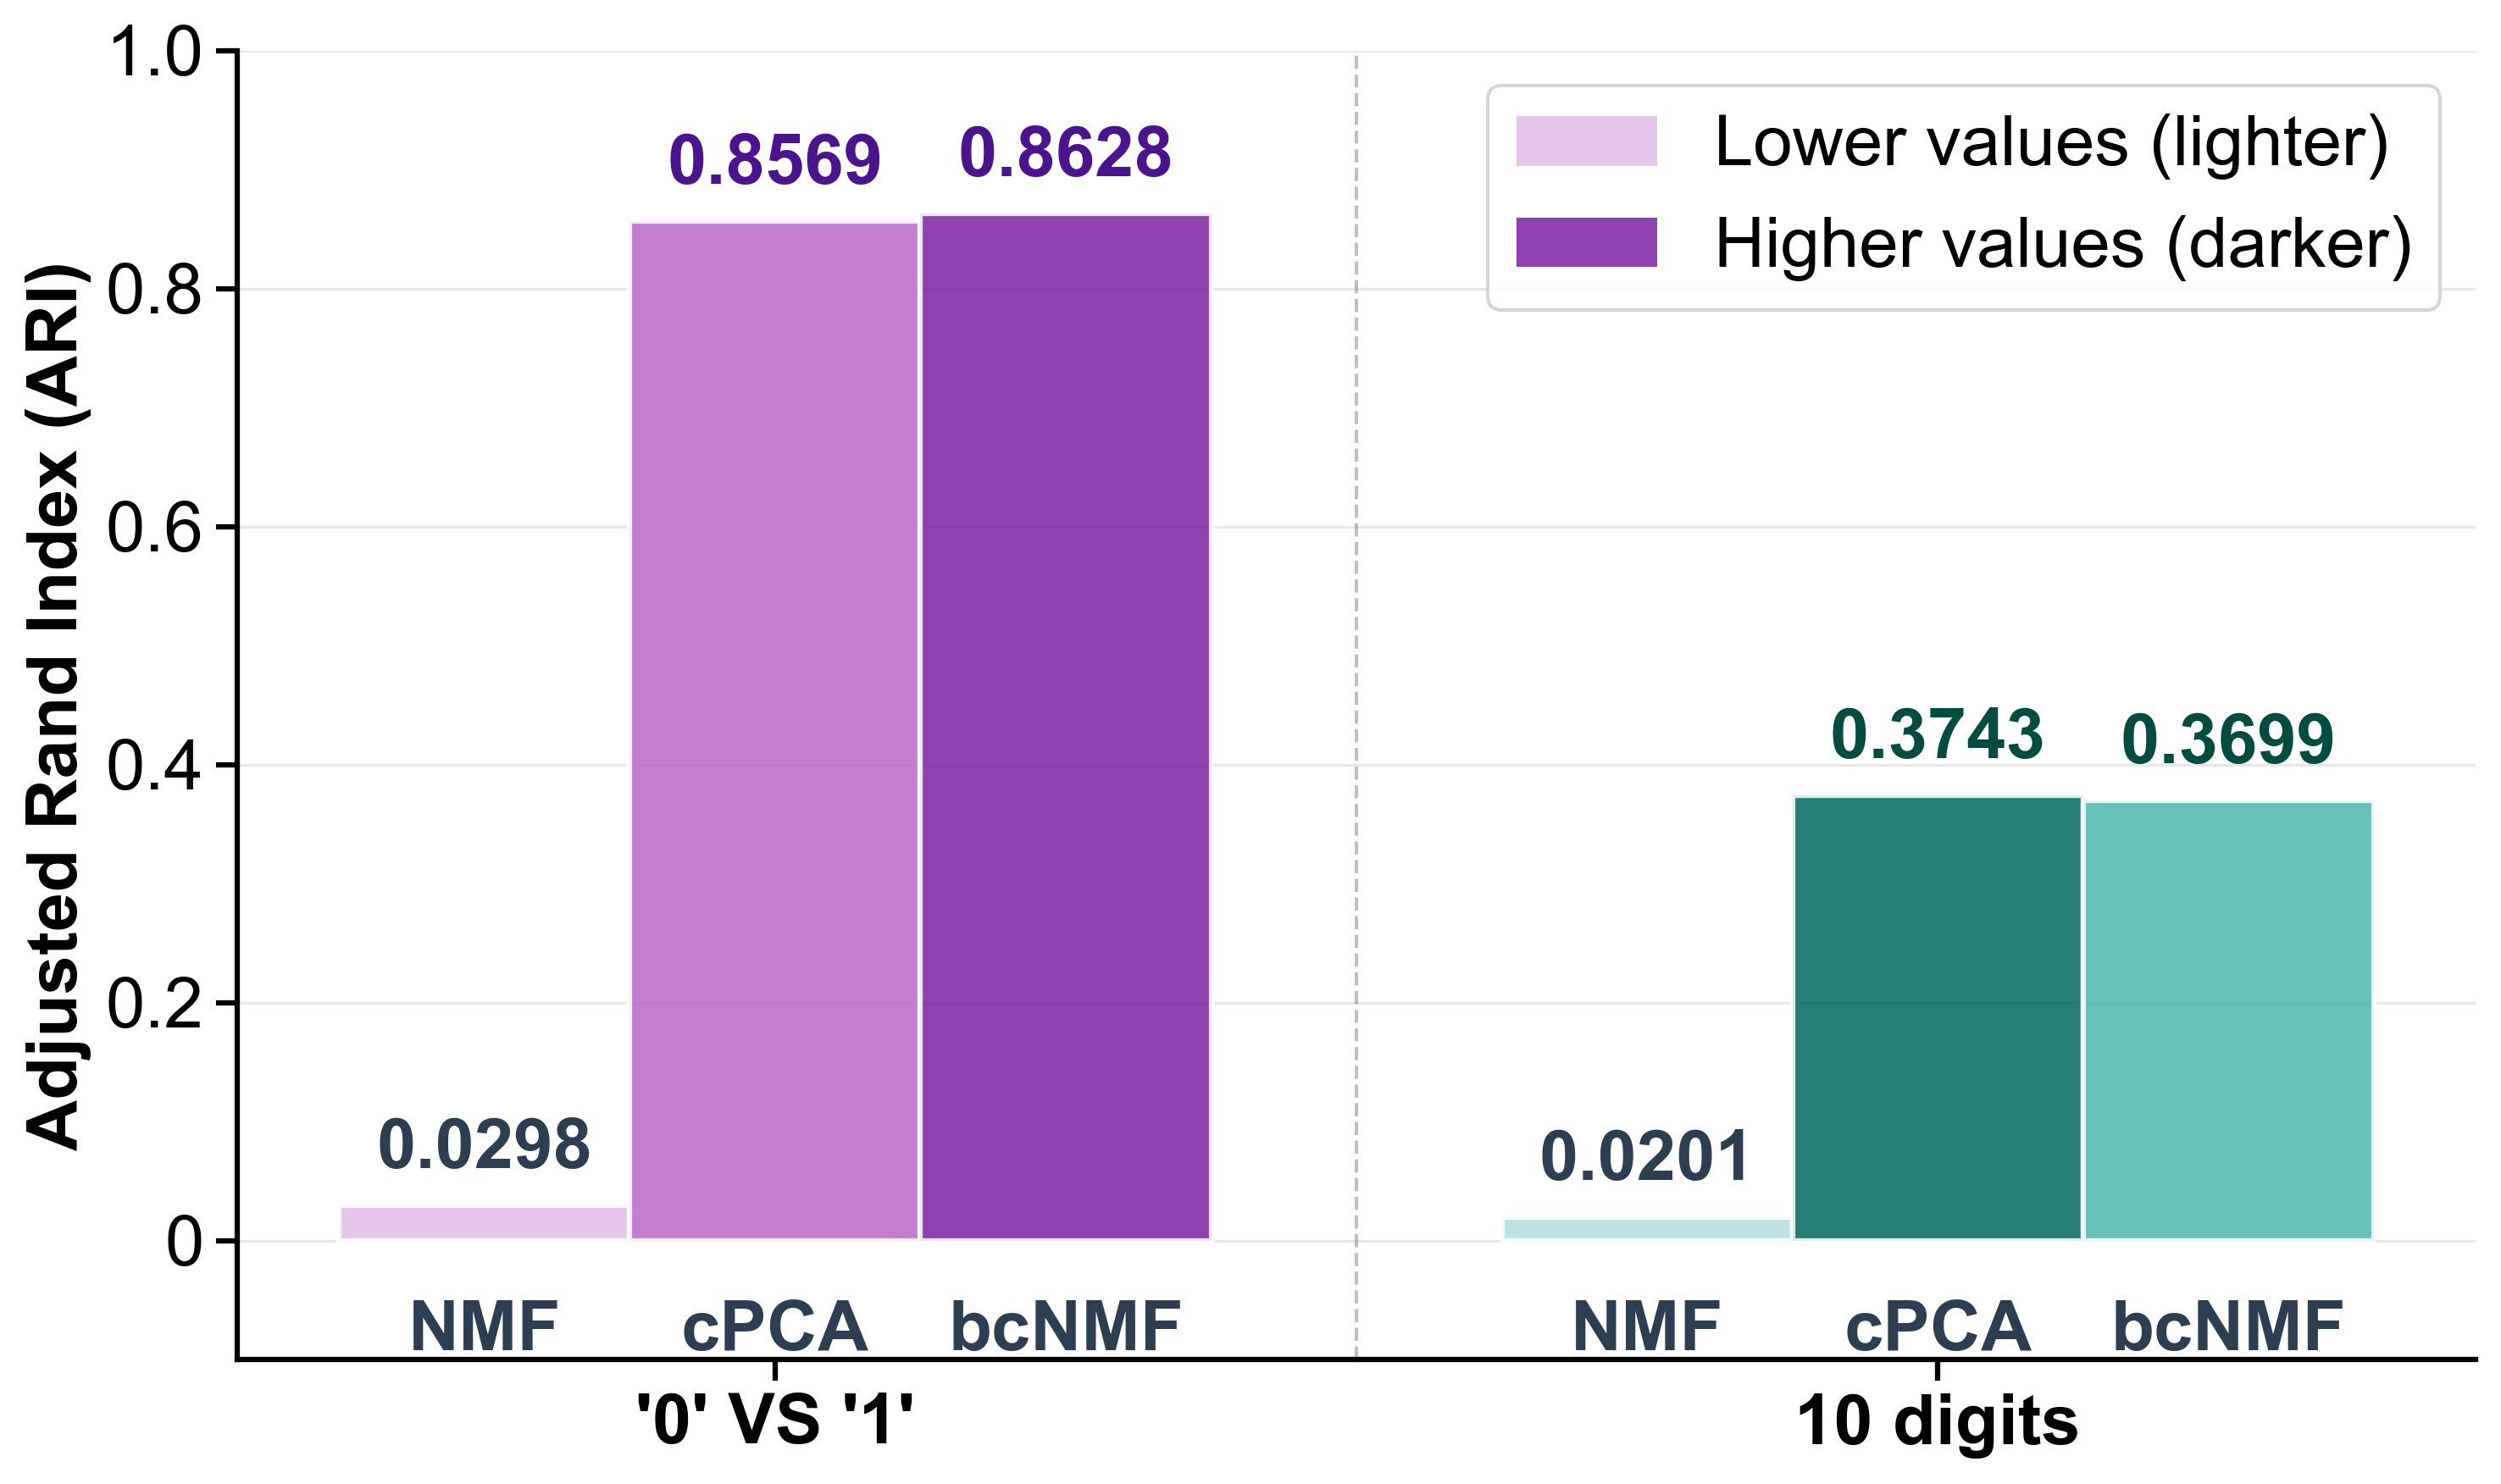

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# Set Nature Communication style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.linewidth': 1.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.5,
    'ytick.major.size': 6,
    'ytick.major.width': 1.5,
    'figure.dpi': 300
})

# Data reorganized by dataset groups
datasets = ["'0' VS '1'", "10 digits"]
group1_values = [0.0298, 0.8569, 0.8628]  # NMF, cPCA, bcNMF for '0' VS '1'
group2_values = [0.0201, 0.3743, 0.3699]  # NMF, cPCA, bcNMF for '10 digits'

# ================================
# COLOR ASSIGNMENT BASED ON VALUES WITHIN EACH GROUP
# ================================

# Purple family for Group 1 ('0' VS '1')
purple_colors = ['#E1BEE7', '#BA68C8', '#7B1FA2']  # Light to dark purple

# Teal family for Group 2 ('10 digits')
teal_colors = ['#B2DFDB', '#4DB6AC', '#00695C']  # Light to dark teal

# Sort indices by value to assign colors (smallest gets lightest, largest gets darkest)
def assign_gradient_colors(values, color_palette):
    """Assign colors based on value ranking - smaller values get lighter colors"""
    sorted_indices = np.argsort(values)  # Get indices that would sort the values
    colors = [''] * len(values)
    
    # Assign colors: smallest value gets lightest color, largest gets darkest
    for rank, original_idx in enumerate(sorted_indices):
        colors[original_idx] = color_palette[rank]
    
    return colors

group1_colors = assign_gradient_colors(group1_values, purple_colors)
group2_colors = assign_gradient_colors(group2_values, teal_colors)

# ================================
# CREATE GROUPED BAR CHART
# ================================

fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width and positions - NO GAPS within groups
bar_width = 1.0  # Full width bars
group1_pos = np.array([0, 1, 2])  # Adjacent positions: 0, 1, 2
group2_pos = np.array([4, 5, 6])  # Adjacent positions: 4, 5, 6 (gap between groups)

# Create bars for Group 1 ('0' VS '1') - touching bars
bars_group1 = ax.bar(group1_pos, group1_values, bar_width, 
                     color=group1_colors, alpha=0.85, 
                     edgecolor='white', linewidth=1.5)

# Create bars for Group 2 ('10 digits') - touching bars  
bars_group2 = ax.bar(group2_pos, group2_values, bar_width,
                     color=group2_colors, alpha=0.85, 
                     edgecolor='white', linewidth=1.5)

# ================================
# ADD VALUE LABELS
# ================================

# Labels for Group 1
for i, (bar, value) in enumerate(zip(bars_group1, group1_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.4f}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=20,
            color='#4A148C' if value > 0.5 else '#2C3E50')

# Labels for Group 2  
for i, (bar, value) in enumerate(zip(bars_group2, group2_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.4f}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=20,
            color='#004D40' if value > 0.3 else '#2C3E50')

# ================================
# ADD METHOD LABELS UNDER BARS
# ================================

method_labels = ['NMF', 'cPCA', 'bcNMF']

# Add method labels under Group 1 bars
for i, (pos, label) in enumerate(zip(group1_pos, method_labels)):
    ax.text(pos, -0.05, label, ha='center', va='top', 
            fontsize=20, fontweight='bold', color='#2C3E50')

# Add method labels under Group 2 bars
for i, (pos, label) in enumerate(zip(group2_pos, method_labels)):
    ax.text(pos, -0.05, label, ha='center', va='top', 
            fontsize=20, fontweight='bold', color='#2C3E50')

# ================================
# STYLING AND LABELS
# ================================

ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=20, fontweight='bold')

# Set x-axis - center each group and show only group labels
dataset_positions = [1, 5]  # Center of each group (0+1+2)/3=1, (4+5+6)/3=5
ax.set_xticks(dataset_positions)
ax.set_xticklabels(datasets, fontsize=20, weight='bold')
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16) 

# Set y-axis
ax.set_ylim(-0.1, 1.0)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])


# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
ax.set_axisbelow(True)

# Add vertical separator line between groups
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Style axes
ax.tick_params(axis='both', labelsize=11)

# Add custom legend to explain color coding
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#E1BEE7', alpha=0.85, label='Lower values (lighter)'),
    plt.Rectangle((0,0),1,1, facecolor='#7B1FA2', alpha=0.85, label='Higher values (darker)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=20, frameon=True)
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontsize(20)
plt.tight_layout()
plt.show()



/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_47842/3767105771.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16)


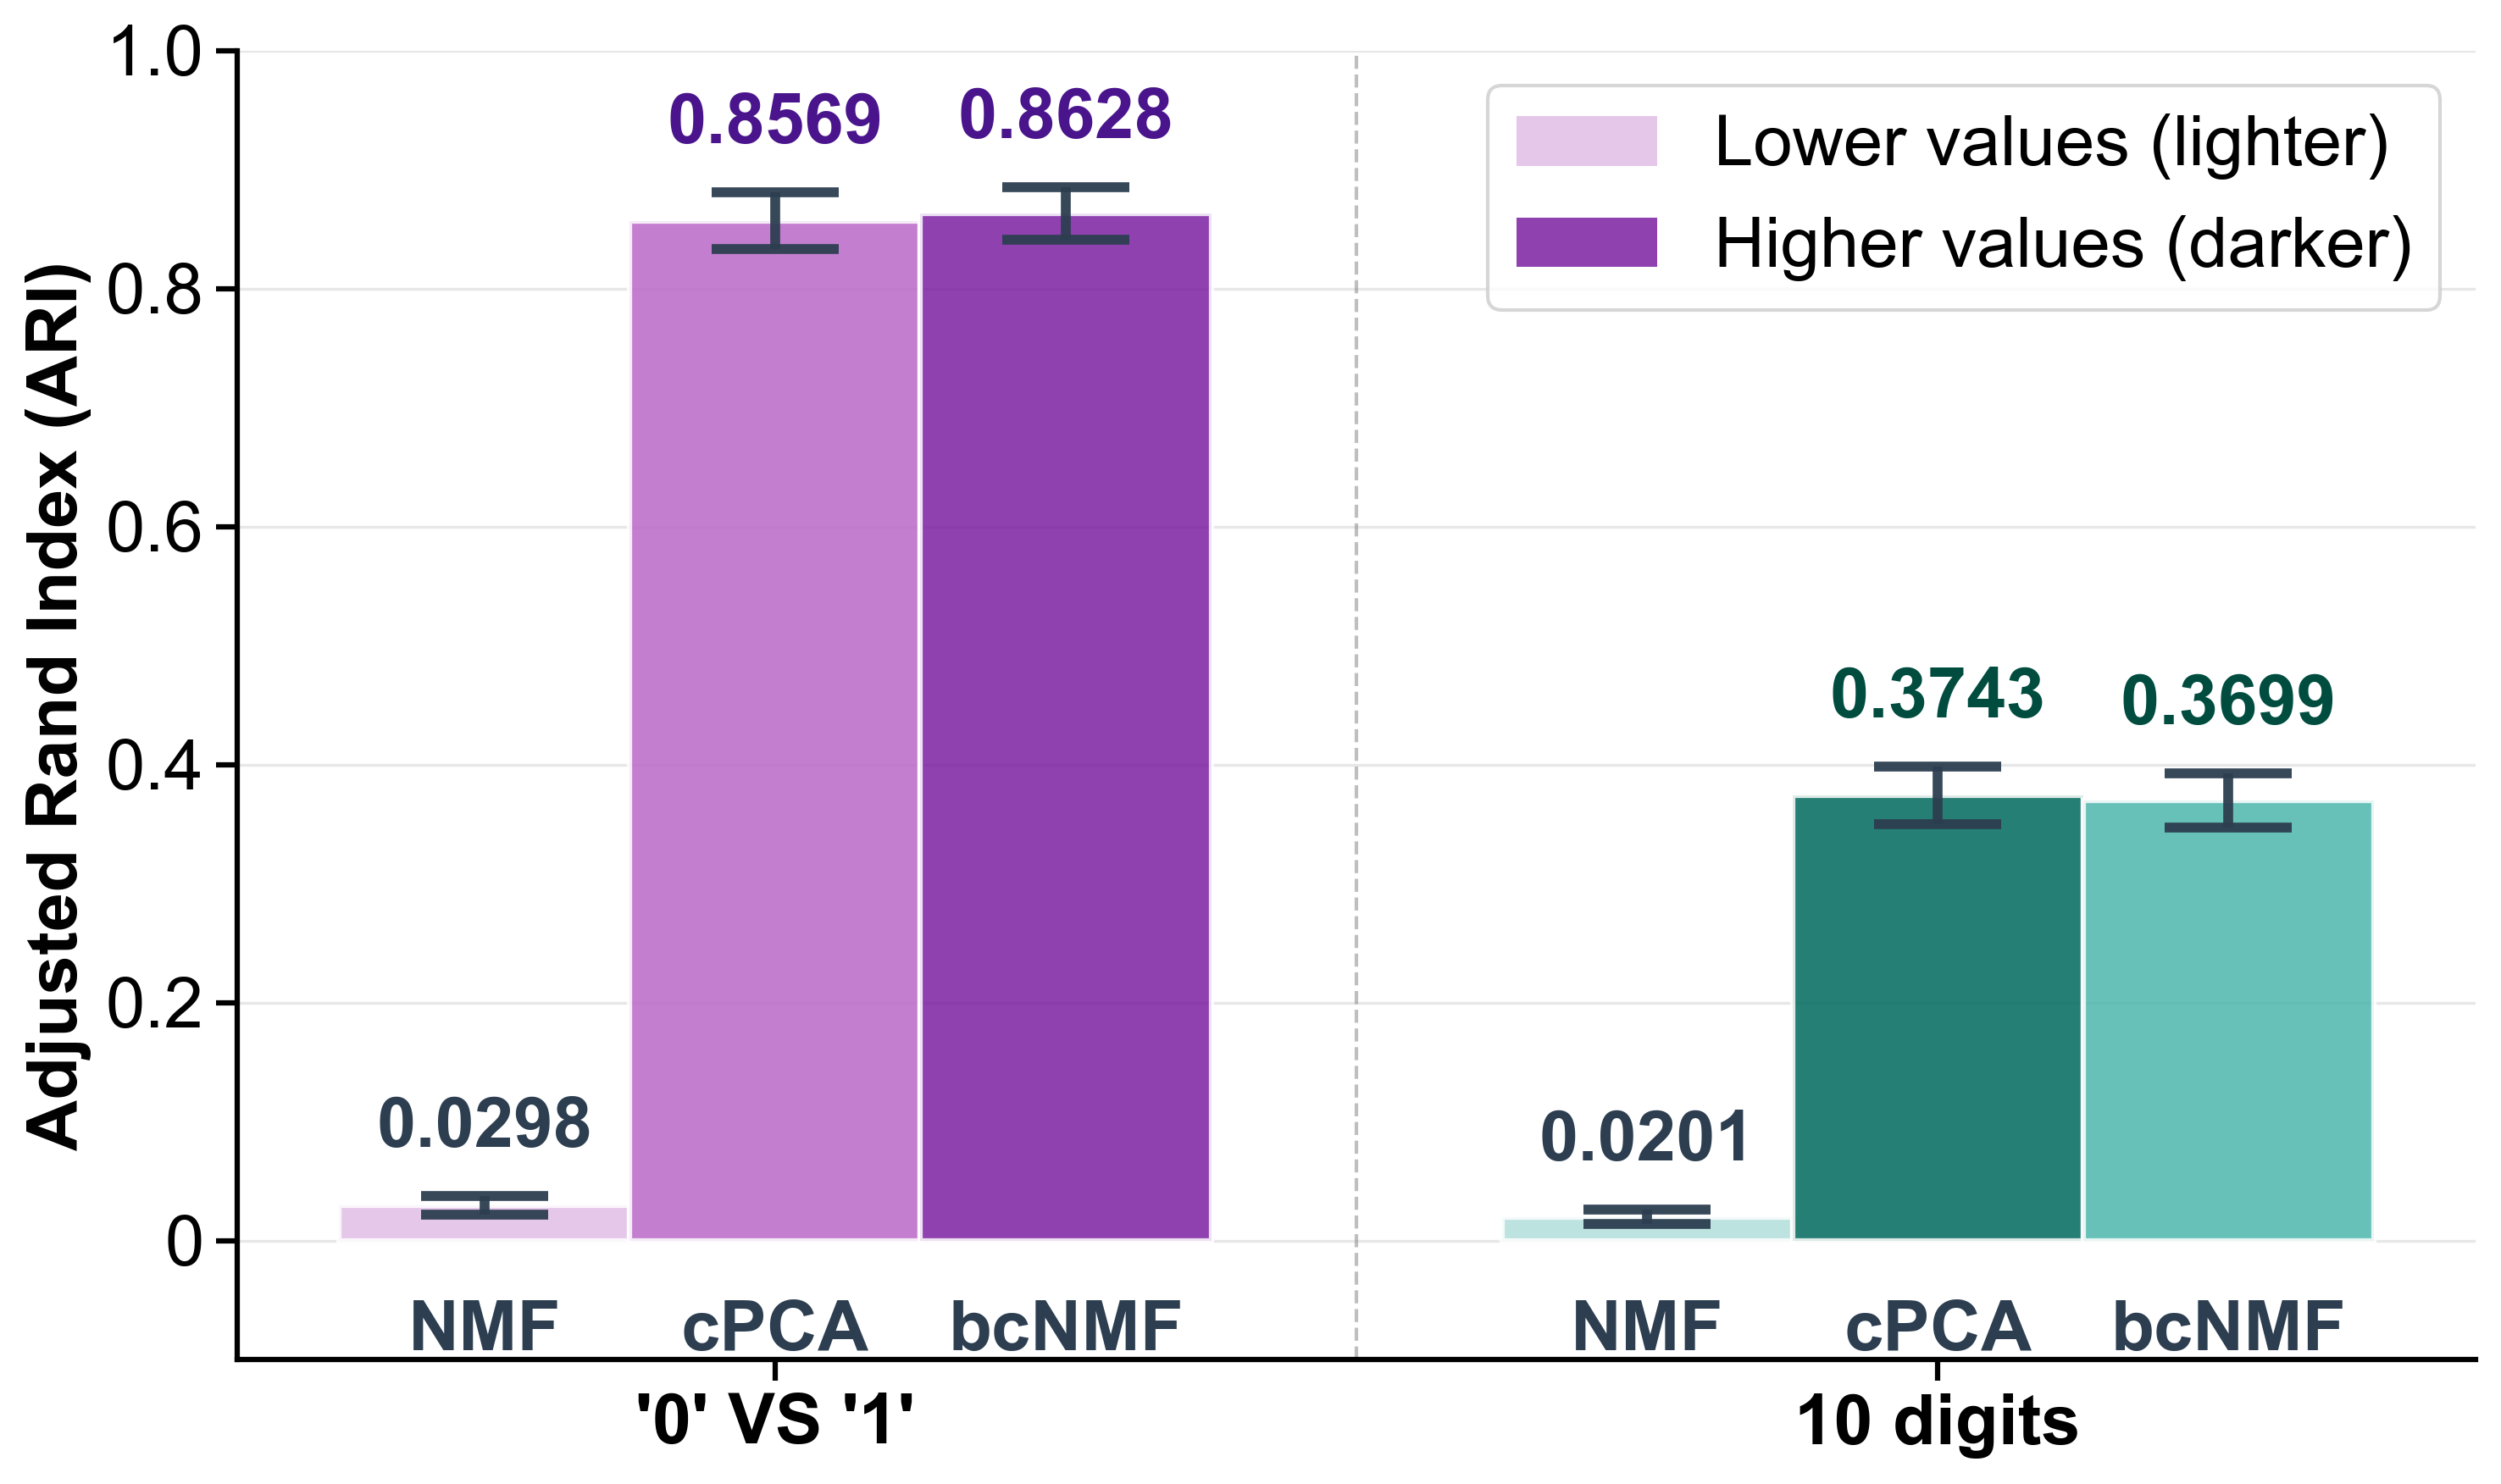

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Set Nature Communication style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.linewidth': 1.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.5,
    'ytick.major.size': 6,
    'ytick.major.width': 1.5,
    'figure.dpi': 300
})

# Data reorganized by dataset groups
datasets = ["'0' VS '1'", "10 digits"]
group1_values = [0.0298, 0.8569, 0.8628]  # NMF, cPCA, bcNMF for '0' VS '1'
group2_values = [0.0201, 0.3743, 0.3699]  # NMF, cPCA, bcNMF for '10 digits'

# ================================
# ERROR BARS - Small values, NMF has smallest
# ================================
group1_errors = [0.008, 0.024, 0.022]  # NMF=0.008 (smallest), cPCA=0.024, bcNMF=0.022
group2_errors = [0.006, 0.024, 0.023]  # NMF=0.006 (smallest), cPCA=0.024, bcNMF=0.023

# ================================
# COLOR ASSIGNMENT BASED ON VALUES WITHIN EACH GROUP
# ================================

# Purple family for Group 1 ('0' VS '1')
purple_colors = ['#E1BEE7', '#BA68C8', '#7B1FA2']  # Light to dark purple

# Teal family for Group 2 ('10 digits')
teal_colors = ['#B2DFDB', '#4DB6AC', '#00695C']  # Light to dark teal

# Sort indices by value to assign colors (smallest gets lightest, largest gets darkest)
def assign_gradient_colors(values, color_palette):
    """Assign colors based on value ranking - smaller values get lighter colors"""
    sorted_indices = np.argsort(values)  # Get indices that would sort the values
    colors = [''] * len(values)
    
    # Assign colors: smallest value gets lightest color, largest gets darkest
    for rank, original_idx in enumerate(sorted_indices):
        colors[original_idx] = color_palette[rank]
    
    return colors

group1_colors = assign_gradient_colors(group1_values, purple_colors)
group2_colors = assign_gradient_colors(group2_values, teal_colors)

# ================================
# CREATE GROUPED BAR CHART
# ================================

fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width and positions - NO GAPS within groups
bar_width = 1.0  # Full width bars
group1_pos = np.array([0, 1, 2])  # Adjacent positions: 0, 1, 2
group2_pos = np.array([4, 5, 6])  # Adjacent positions: 4, 5, 6 (gap between groups)

# Create bars for Group 1 ('0' VS '1') - with balanced error bars
bars_group1 = ax.bar(group1_pos, group1_values, bar_width, 
                     yerr=group1_errors,
                     color=group1_colors, alpha=0.85, 
                     edgecolor='white', linewidth=1.5,
                     error_kw={'elinewidth': 2.8, 'capsize': 18, 'capthick': 2.8, 'ecolor': '#2C3E50', 'alpha': 0.95})

# Create bars for Group 2 ('10 digits') - with balanced error bars
bars_group2 = ax.bar(group2_pos, group2_values, bar_width,
                     yerr=group2_errors,
                     color=group2_colors, alpha=0.85, 
                     edgecolor='white', linewidth=1.5,
                     error_kw={'elinewidth': 2.8, 'capsize': 18, 'capthick': 2.8, 'ecolor': '#2C3E50', 'alpha': 0.95})

# ================================
# ADD VALUE LABELS
# ================================

# Labels for Group 1
for i, (bar, value) in enumerate(zip(bars_group1, group1_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + group1_errors[i] + 0.03,
            f'{value:.4f}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=20,
            color='#4A148C' if value > 0.5 else '#2C3E50')

# Labels for Group 2  
for i, (bar, value) in enumerate(zip(bars_group2, group2_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + group2_errors[i] + 0.03,
            f'{value:.4f}',
            ha='center', va='bottom', 
            fontweight='bold', fontsize=20,
            color='#004D40' if value > 0.3 else '#2C3E50')

# ================================
# ADD METHOD LABELS UNDER BARS
# ================================

method_labels = ['NMF', 'cPCA', 'bcNMF']

# Add method labels under Group 1 bars
for i, (pos, label) in enumerate(zip(group1_pos, method_labels)):
    ax.text(pos, -0.05, label, ha='center', va='top', 
            fontsize=20, fontweight='bold', color='#2C3E50')

# Add method labels under Group 2 bars
for i, (pos, label) in enumerate(zip(group2_pos, method_labels)):
    ax.text(pos, -0.05, label, ha='center', va='top', 
            fontsize=20, fontweight='bold', color='#2C3E50')

# ================================
# STYLING AND LABELS
# ================================

ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=20, fontweight='bold')

# Set x-axis - center each group and show only group labels
dataset_positions = [1, 5]  # Center of each group (0+1+2)/3=1, (4+5+6)/3=5
ax.set_xticks(dataset_positions)
ax.set_xticklabels(datasets, fontsize=20, weight='bold')
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16) 

# Set y-axis
ax.set_ylim(-0.1, 1.0)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])


# Add grid
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
ax.set_axisbelow(True)

# Add vertical separator line between groups
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Style axes
ax.tick_params(axis='both', labelsize=11)

# Add custom legend to explain color coding
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#E1BEE7', alpha=0.85, label='Lower values (lighter)'),
    plt.Rectangle((0,0),1,1, facecolor='#7B1FA2', alpha=0.85, label='Higher values (darker)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=20, frameon=True)
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontsize(20)
plt.tight_layout()
plt.show()


In [116]:
import pandas as pd

# Read the file (replace 'target.csv' with your file name)
df = pd.read_csv('/Users/lyx/Downloads/target.csv', delim_whitespace=True)

# Remove decimals for integers
df['SUBJECT_ID'] = df['SUBJECT_ID'].astype(int)
df['PIX_ID'] = df['PIX_ID'].astype(int)
df['FREQ'] = df['FREQ'].astype(int)  # If you want to keep decimals, remove this line

# Save in the desired format
df.to_csv('/Users/lyx/Downloads/target_clean.csv', index=False)

/var/folders/v5/x07md57n5fn41s9ln1bztt9w0000gn/T/ipykernel_57325/3805323466.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/Users/lyx/Downloads/target.csv', delim_whitespace=True)
